<style>
:root { --navy:#172033; --blue:#2563eb; --cyan:#06b6d4; --paper:#f8fafc; --line:#dbeafe; }
.lab-hero { padding:32px 36px; border-radius:20px; color:white; background:linear-gradient(125deg,#172033 0%,#1d4ed8 60%,#06b6d4 100%); box-shadow:0 12px 28px rgba(37,99,235,.22); }
.lab-hero h1 { margin:0 0 8px; font-size:34px; letter-spacing:-.7px; }
.lab-hero p { margin:6px 0; opacity:.94; }
.lab-grid { display:grid; grid-template-columns:repeat(3,minmax(0,1fr)); gap:12px; margin:18px 0; }
.lab-card { padding:16px; border:1px solid var(--line); border-radius:14px; background:var(--paper); }
.lab-card b { color:var(--blue); }
.lab-note { border-left:5px solid var(--cyan); padding:12px 16px; background:#ecfeff; border-radius:8px; }
.lab-pending { border-left:5px solid #f59e0b; padding:12px 16px; background:#fffbeb; border-radius:8px; }
table { font-size:13px !important; }
</style>

<div class="lab-hero">
  <h1>Laboratorio 7 · Spark MLlib</h1>
  <p><b>Actividades 1–8: exploración, segmentación, modelado, evaluación en 2026 y análisis de errores</b> · ENEIC Personas 2025–2026</p>
  <p>Universidad del Valle de Guatemala · CC3084 Data Science · Sección 10 · Grupo 1 · Segundo semestre 2026</p>
</div>

<div class="lab-grid">
  <div class="lab-card"><b>Jorge Gabriel Palacios Sales</b><br>231385</div>
  <div class="lab-card"><b>Pablo Daniel Barillas Moreno</b><br>22193</div>
  <div class="lab-card"><b>Roberto Emiliano Otoniel</b><br>23968</div>
</div>

## 0. Objetivo, preguntas y alcance

Este notebook identifica perfiles de trabajadores asalariados y evalúa qué tan bien puede estimarse su salario mensual mediante Spark 3.5.1 y `pyspark.ml`. El procedimiento conserva la trazabilidad por archivo, evita interpretar asociaciones como causalidad y calcula las métricas sobre los conjuntos completos.

**Alcance ejecutado:** actividades 1–8. La sección 8 analiza los errores sobre las predicciones de 2026T1 que deja guardadas la sección 7.

**Diseño temporal:** 2025T1–2025T3 se utilizan para entrenamiento; 2025T4 para validación y selección. Después, cada configuración ganadora se reentrena con los cuatro trimestres de 2025 y se evalúa una sola vez en 2026T1. 2026T1 nunca se consulta para escoger configuraciones.

In [1]:
from pathlib import Path
import platform
import sys

from IPython.display import HTML, Image, Markdown, display
import pandas as pd
import pyspark
from pyspark.sql import SparkSession, functions as F

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "src").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from lab7.config import (
    FIGURES_DIR, FINAL_FOREST_MODEL, FINAL_LINEAR_MODEL, FINAL_TRAIN_PERIODS,
    MODEL_DIR, TABLES_DIR, TEST_PERIODS, TRAIN_PERIODS, VALIDATION_PERIODS,
    ensure_directories,
)
from lab7.data import (
    convert_excel_sources, counts_by_file, duplicate_key_audit,
    filter_analytical_population, harmonize, load_periods,
    missingness_before_filters, observed_source_quarters, save_prepared_sets,
)
from lab7.analysis import (
    categorical_distribution, descriptive_statistics, error_by_group,
    error_by_salary_band, kmeans_search, load_test_predictions, median_salary_by,
    pearson_correlation, plot_comparison_sample, quarterly_summary,
    residual_summary, salary_percentile_bands, salary_plot_sample,
)
from lab7.interpretation import (
    band_context, band_findings, final_discussion, group_findings,
    plot_findings, question_answers, salary_scale_sentence,
)
from lab7.modeling import (
    baseline_metrics, comparison_table, final_comparison_table,
    fit_final_models, fit_linear_candidates, fit_random_forest_candidates,
)
from lab7.visualization import (
    plot_actual_vs_predicted, plot_categorical_distributions,
    plot_correlation_heatmap, plot_errors_by_domain, plot_errors_by_education,
    plot_errors_by_salary_band, plot_group_medians, plot_kmeans_selection,
    plot_model_comparison, plot_quarterly_summary, plot_residuals,
    plot_salary_distribution,
)

ensure_directories()
spark = (
    SparkSession.builder
    .appName("Lab7-ENEIC-SparkMLlib")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

versions = pd.DataFrame({
    "componente": ["Python", "PySpark", "Java", "Semilla"],
    "valor": [platform.python_version(), pyspark.__version__, spark.sparkContext._jvm.java.lang.System.getProperty("java.version"), "42"],
})
display(versions)
assert pyspark.__version__.startswith("3.5"), "La guía requiere Spark 3.5.x"

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/28 13:59:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


,componente,valor
0,Python,3.11.16
1,PySpark,3.5.1
2,Java,17.0.20.1
3,Semilla,42


## 1. Carga, armonización y calidad

Cada Excel se procesa por separado y únicamente con las 14 columnas requeridas. Primero se crea un DataFrame de Spark con esquema explícito de texto —para evitar inferencias distintas entre trimestres— y luego se guarda en Parquet. Las conversiones numéricas y categóricas se realizan posteriormente en Spark.

In [2]:
conversion_audit = convert_excel_sources(spark, force=False)
display(conversion_audit)
assert (conversion_audit["registros"] == conversion_audit["esperados"]).all()

raw_2025 = load_periods(spark, ["2025T1", "2025T2", "2025T3", "2025T4"]).cache()
raw_2026 = load_periods(spark, ["2026T1"]).cache()
harmonized_2025 = harmonize(raw_2025).cache()
harmonized_2026 = harmonize(raw_2026).cache()

selected_view = [
    "periodo_archivo", "archivo_origen", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA",
    "edad", "ocupado", "categoria_ocupacional", "salario_mensual", "antiguedad",
    "horas_semanales", "nivel_educativo", "dominio", "factor",
]
harmonized_2025.select(*selected_view).printSchema()
harmonized_2025.select(*selected_view).show(5, truncate=False)

,periodo_archivo,archivo_origen,registros,esperados,estado
0,2025T1,Personas_ENEIC_I_2025.xlsx,51588,51588,Parquet reutilizado
1,2025T2,Personas_ENEIC_II_2025.xlsx,51167,51167,Parquet reutilizado
2,2025T3,Personas_ENEIC_III_2025.xlsx,51583,51583,Parquet reutilizado
3,2025T4,Personas_ENEIC_IV_2025.xlsx,49338,49338,Parquet reutilizado
4,2026T1,Personas_ENEIC_I_2026.xlsx,49843,49843,Parquet reutilizado


26/09/28 13:59:41 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


root
 |-- periodo_archivo: string (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- edad: double (nullable = true)
 |-- ocupado: double (nullable = true)
 |-- categoria_ocupacional: string (nullable = false)
 |-- salario_mensual: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = false)
 |-- dominio: string (nullable = false)
 |-- factor: double (nullable = true)



+---------------+--------------------------+---------+---------+-----------+----+-------+---------------------------+---------------+----------+---------------+---------------+--------------------+------+
|periodo_archivo|archivo_origen            |TRIMESTRE|NUM_HOGAR|NUM_PERSONA|edad|ocupado|categoria_ocupacional      |salario_mensual|antiguedad|horas_semanales|nivel_educativo|dominio             |factor|
+---------------+--------------------------+---------+---------+-----------+----+-------+---------------------------+---------------+----------+---------------+---------------+--------------------+------+
|2025T1         |Personas_ENEIC_I_2025.xlsx|2        |751      |1          |46.0|1.0    |DESCONOCIDO                |NULL           |25.0      |14.0           |Ninguno        |Rural Nacional      |456.0 |
|2025T1         |Personas_ENEIC_I_2025.xlsx|2        |3557     |2          |36.0|NULL   |DESCONOCIDO                |NULL           |NULL      |NULL           |Primaria       |Rest

In [3]:
missingness_2025 = missingness_before_filters(raw_2025)
prepared_2025, filter_audit_2025 = filter_analytical_population(harmonized_2025)
prepared_2026, filter_audit_2026 = filter_analytical_population(harmonized_2026)
prepared_2025 = prepared_2025.cache()
prepared_2026 = prepared_2026.cache()

file_counts = counts_by_file(harmonized_2025, prepared_2025)
source_quarters = observed_source_quarters(raw_2025)
key_audit = duplicate_key_audit(harmonized_2025)

for name, table in {
    "conversion_fuentes.csv": conversion_audit,
    "faltantes_antes_filtros_2025.csv": missingness_2025,
    "auditoria_filtros_2025.csv": filter_audit_2025,
    "auditoria_filtros_2026.csv": filter_audit_2026,
    "conteos_por_archivo.csv": file_counts,
    "trimestre_fuente_observado.csv": source_quarters,
    "auditoria_claves.csv": key_audit,
}.items():
    table.to_csv(TABLES_DIR / name, index=False)

display(HTML("<h4>Faltantes antes de filtrar (2025)</h4>"))
display(missingness_2025.style.format({"porcentaje": "{:.2f}%"}))
display(HTML("<h4>Embudo de filtros 2025</h4>"))
display(filter_audit_2025)
display(HTML("<h4>Conteos por archivo</h4>"))
display(file_counts.style.format({"retencion_pct": "{:.2f}%"}))
display(HTML("<h4>TRIMESTRE original conservado</h4>"))
display(source_quarters)
display(HTML("<h4>Unicidad de periodo + hogar + persona</h4>"))
display(key_audit)

save_prepared_sets(prepared_2025, prepared_2026)

,variable,faltantes,porcentaje
8,P05D01,150651,73.97%
6,OCUPADOS,115454,56.69%
9,P05C07A,115454,56.69%
10,P05C07B,115454,56.69%
7,P05C16,115454,56.69%
11,P05H01A,115454,56.69%
12,P03A03A,26344,12.93%
3,ANIO,0,0.00%
13,DOMINIO,0,0.00%
2,FACTOR,0,0.00%


,paso,criterio,antes,excluidos,despues
0,0,Registros de entrada,203676,0,203676
1,1,Edad finita y >= 15,203676,62886,140790
2,2,Persona ocupada (OCUPADOS = 1),140790,52568,88222
3,3,"Categoria asalariada (P05C16 en 1,2,3,4)",88222,35197,53025
4,4,Salario finito y positivo,53025,0,53025
5,5,Componentes de antiguedad validos,53025,0,53025
6,6,Antiguedad <= edad,53025,0,53025
7,7,"Horas semanales en (0, 168]",53025,0,53025


,periodo_archivo,antes,despues,excluidos,retencion_pct
0,2025T1,51588,13419,38169,26.01%
1,2025T2,51167,13492,37675,26.37%
2,2025T3,51583,13450,38133,26.07%
3,2025T4,49338,12664,36674,25.67%


,periodo_archivo,TRIMESTRE,count
0,2025T1,2,51588
1,2025T2,2,175
2,2025T2,3,50992
3,2025T3,4,51583
4,2025T4,5,49338


,grupos_duplicados,filas_involucradas,grupos_repeticion_exacta,grupos_en_conflicto
0,0,0,0,0


26/09/28 14:00:05 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


26/09/28 14:00:06 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


26/09/28 14:00:13 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


### Interpretación de calidad

- **2025-IV no se apila por posición:** contiene 302 columnas frente a 270 en los otros archivos. `unionByName` evita asociar variables distintas por su posición física.
- **Ausente por diseño vs. no respuesta:** una pregunta puede no corresponder por el flujo del cuestionario; una no respuesta sí era aplicable, pero quedó sin registrar. Ambos casos pueden verse vacíos, aunque tienen significados estadísticos diferentes.
- **Longitudinalidad:** la misma persona en dos períodos es una observación válida distinta; solo se audita la unicidad dentro de `periodo_archivo`.
- **Alcance:** la base filtrada no representa por sí sola a todos los trabajadores de Guatemala. Este análisis no ponderado describe registros elegibles. `FACTOR` se conserva para una futura estimación poblacional con el diseño muestral apropiado.
- Los códigos categóricos desconocidos se representan como `DESCONOCIDO`; el código educativo 0 se conserva como `Ninguno`.

## 2. Estadística descriptiva y exploración

,variable,n,media,mediana,desviacion_estandar,minimo,p25,p75,p95,maximo
0,salario_mensual,53025,"3,421.68","3,000.00","2,902.11",1.00,"1,800.00","4,000.00","8,000.00","99,000.00"
1,edad,53025,35.19,33.00,13.52,15.00,24.00,44.00,61.00,89.00
2,antiguedad,53025,5.56,2.00,7.83,0.00,0.50,7.00,21.33,70.00
3,horas_semanales,53025,46.31,45.00,18.63,1.00,40.00,55.00,80.00,126.00


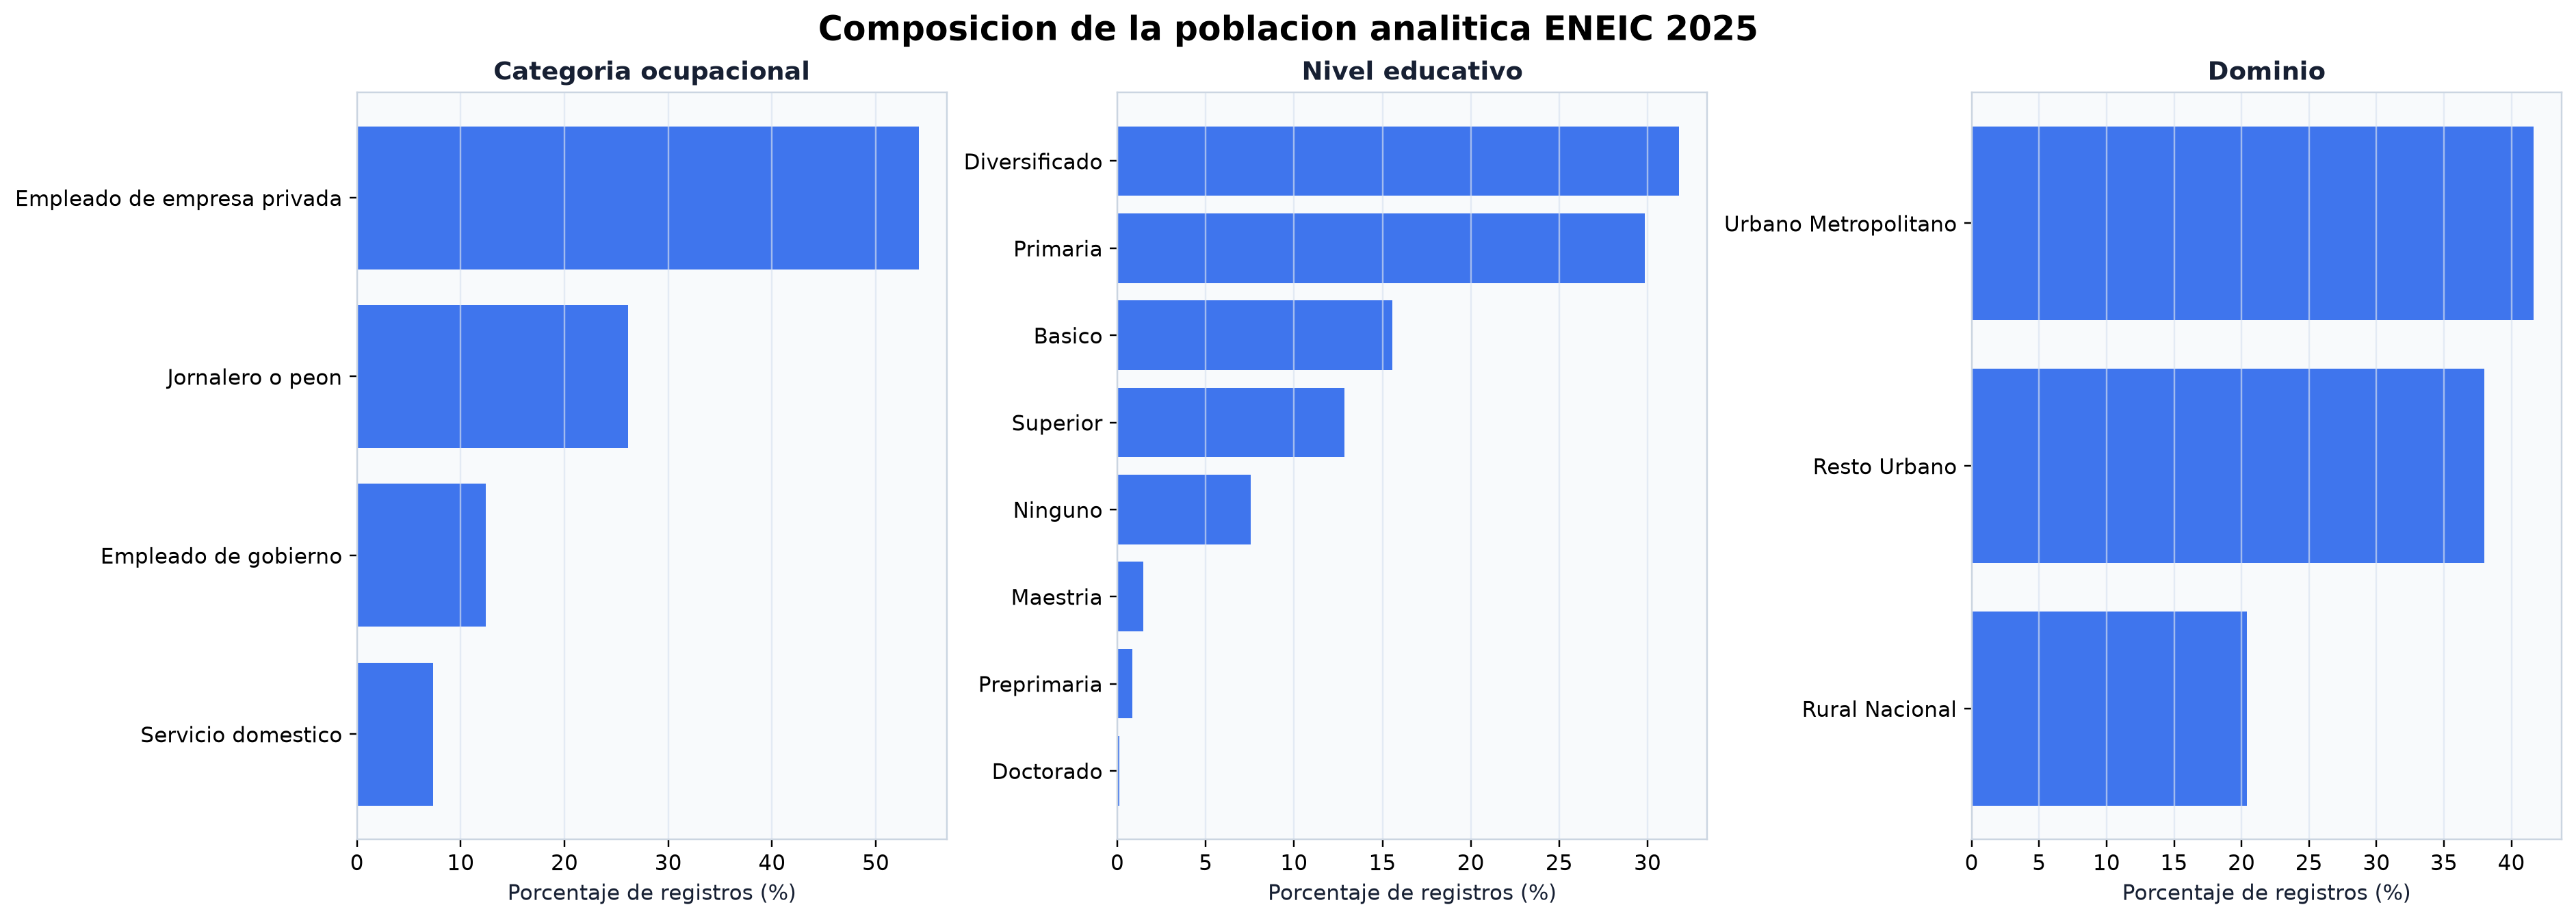

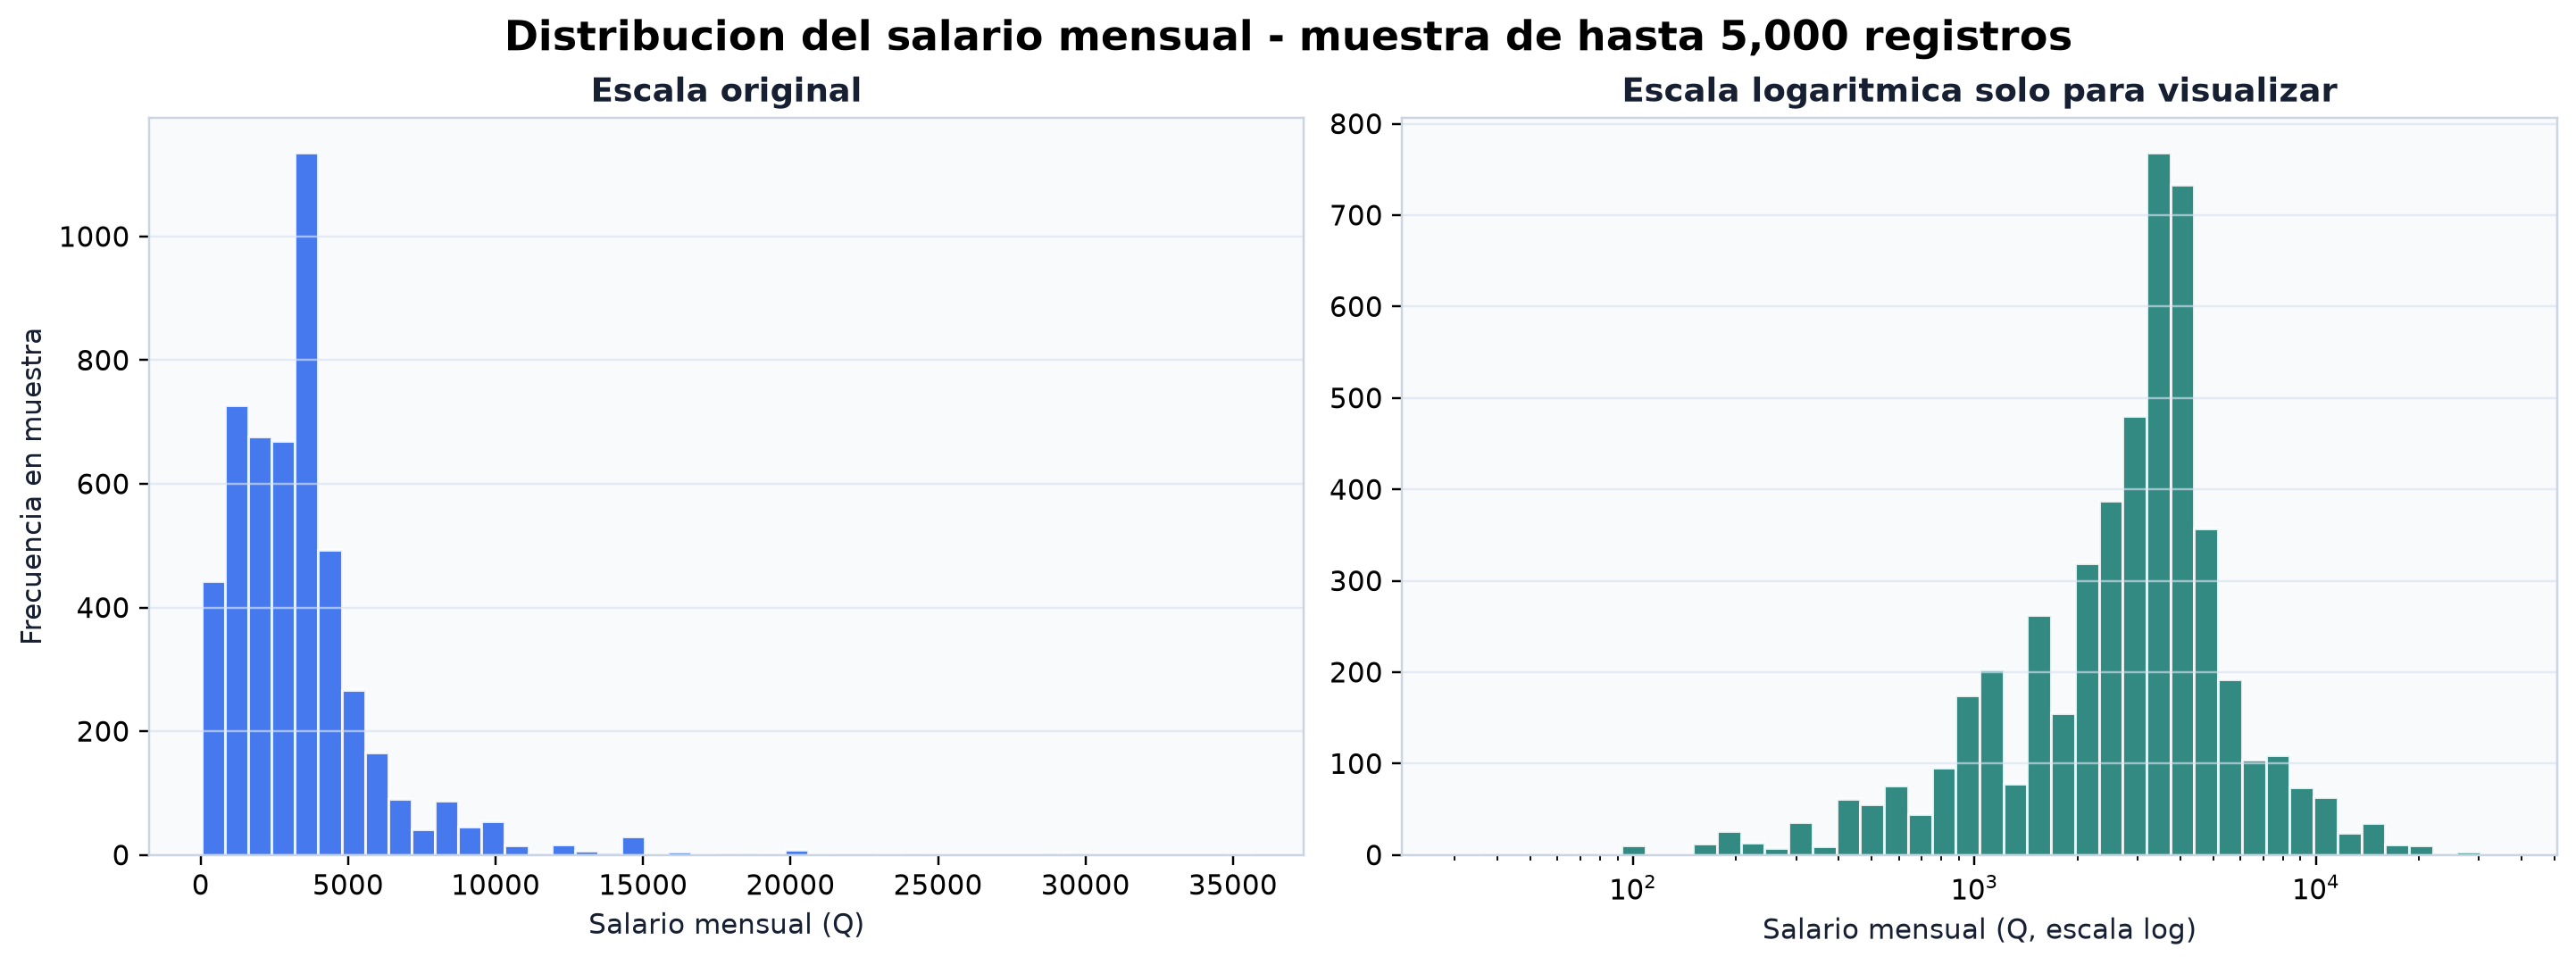

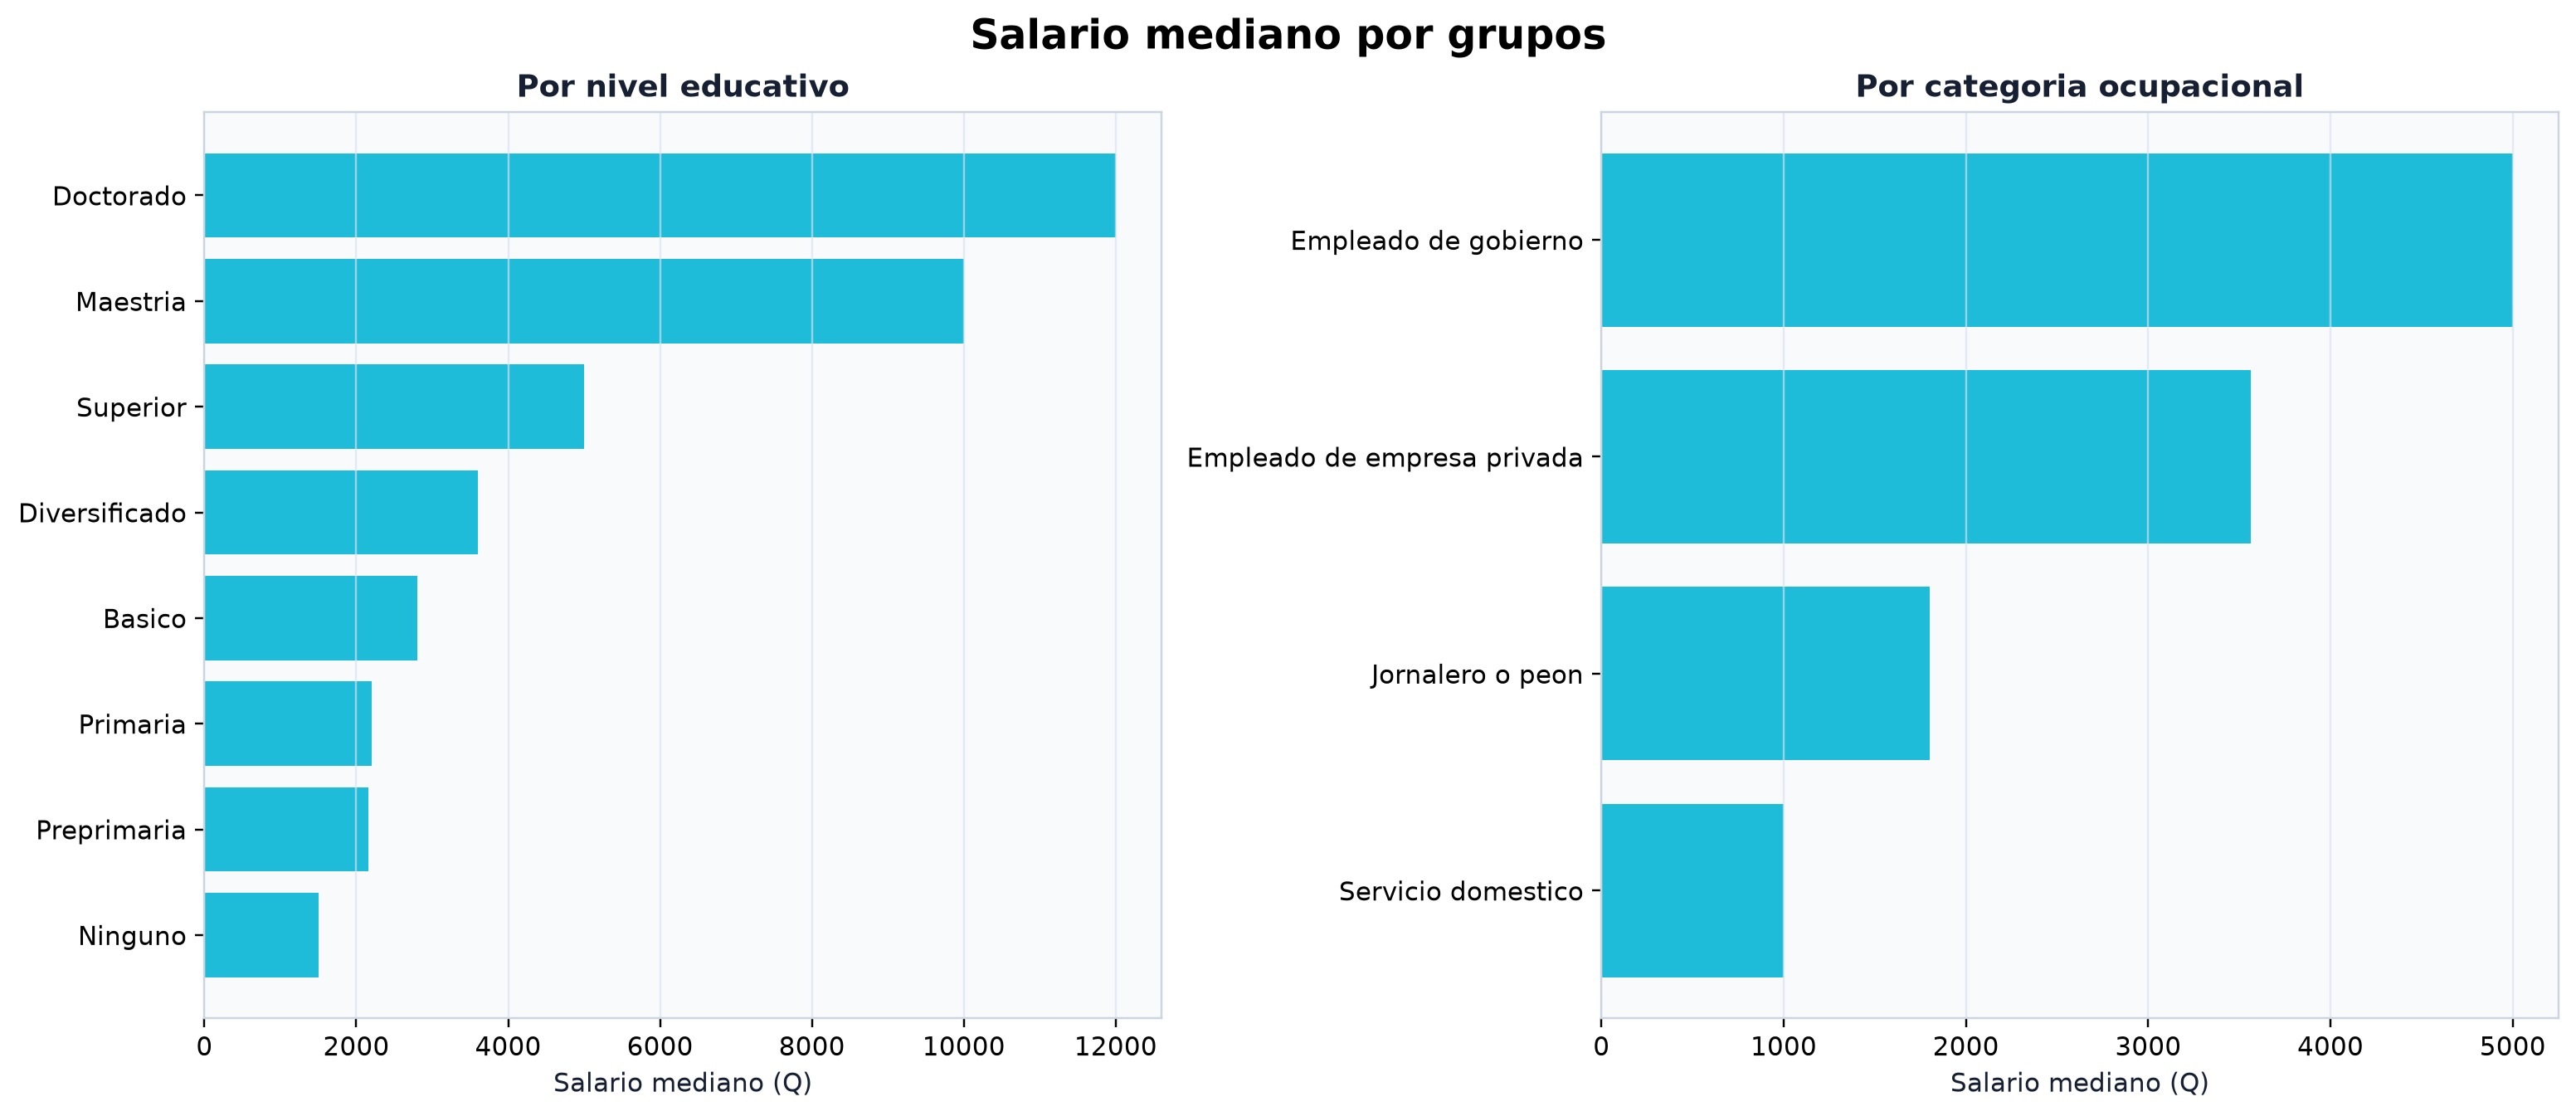

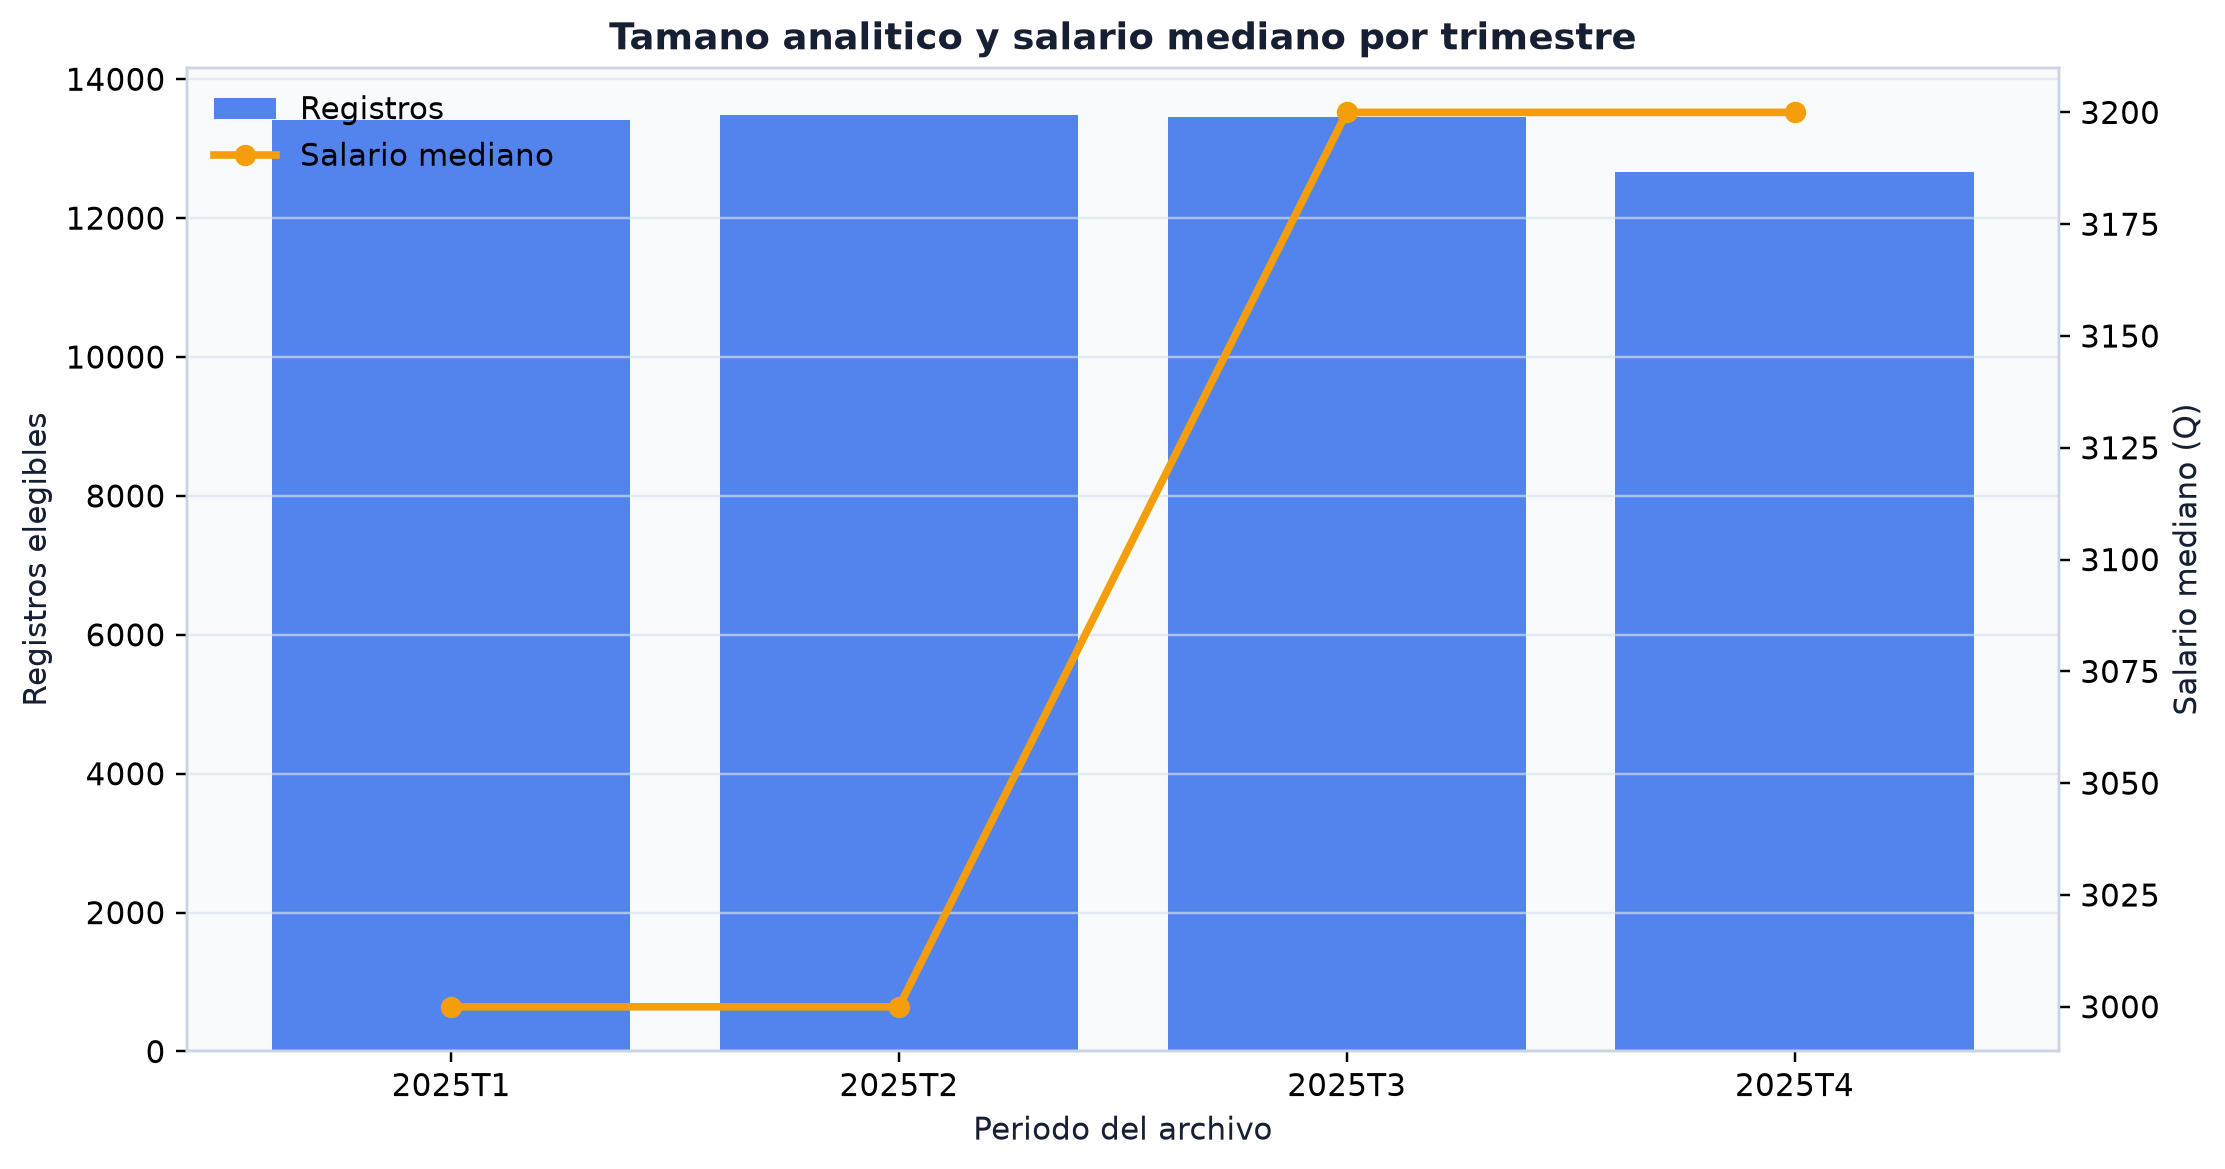

In [4]:
descriptive = descriptive_statistics(prepared_2025)
distributions = pd.concat([
    categorical_distribution(prepared_2025, "categoria_ocupacional"),
    categorical_distribution(prepared_2025, "nivel_educativo"),
    categorical_distribution(prepared_2025, "dominio"),
], ignore_index=True)
salary_groups = pd.concat([
    median_salary_by(prepared_2025, "nivel_educativo"),
    median_salary_by(prepared_2025, "categoria_ocupacional"),
], ignore_index=True)
quarters = quarterly_summary(prepared_2025)
salary_sample = salary_plot_sample(prepared_2025, 5_000)

descriptive.to_csv(TABLES_DIR / "estadistica_descriptiva_2025.csv", index=False)
distributions.to_csv(TABLES_DIR / "distribuciones_categoricas.csv", index=False)
salary_groups.to_csv(TABLES_DIR / "salario_por_grupo.csv", index=False)
quarters.to_csv(TABLES_DIR / "resumen_trimestral.csv", index=False)

plot_categorical_distributions(distributions)
plot_salary_distribution(salary_sample)
plot_group_medians(salary_groups)
plot_quarterly_summary(quarters)

display(descriptive.style.format({c: "{:,.2f}" for c in descriptive.columns if c not in ["variable", "n"]}))
display(Image(filename=str(FIGURES_DIR / "distribuciones_categoricas.png")))
display(Image(filename=str(FIGURES_DIR / "distribucion_salario.png")))
display(Image(filename=str(FIGURES_DIR / "salario_mediano_grupos.png")))
display(Image(filename=str(FIGURES_DIR / "evolucion_trimestral.png")))

salary_row = descriptive.loc[descriptive["variable"] == "salario_mensual"].iloc[0]
shape = "asimetría positiva" if salary_row["media"] > salary_row["mediana"] else "asimetría negativa o débil"
display(HTML(f'''
<div class='lab-note'><b>Lectura descriptiva.</b> El salario presenta {shape}: la media es Q{salary_row['media']:,.2f} y la mediana Q{salary_row['mediana']:,.2f}. La diferencia y el máximo elevado justifican conservar los extremos para modelar, pero interpretar RMSE junto con MAE.</div>
'''))

## 3. Relaciones entre variables numéricas

26/09/28 14:00:31 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/28 14:00:31 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


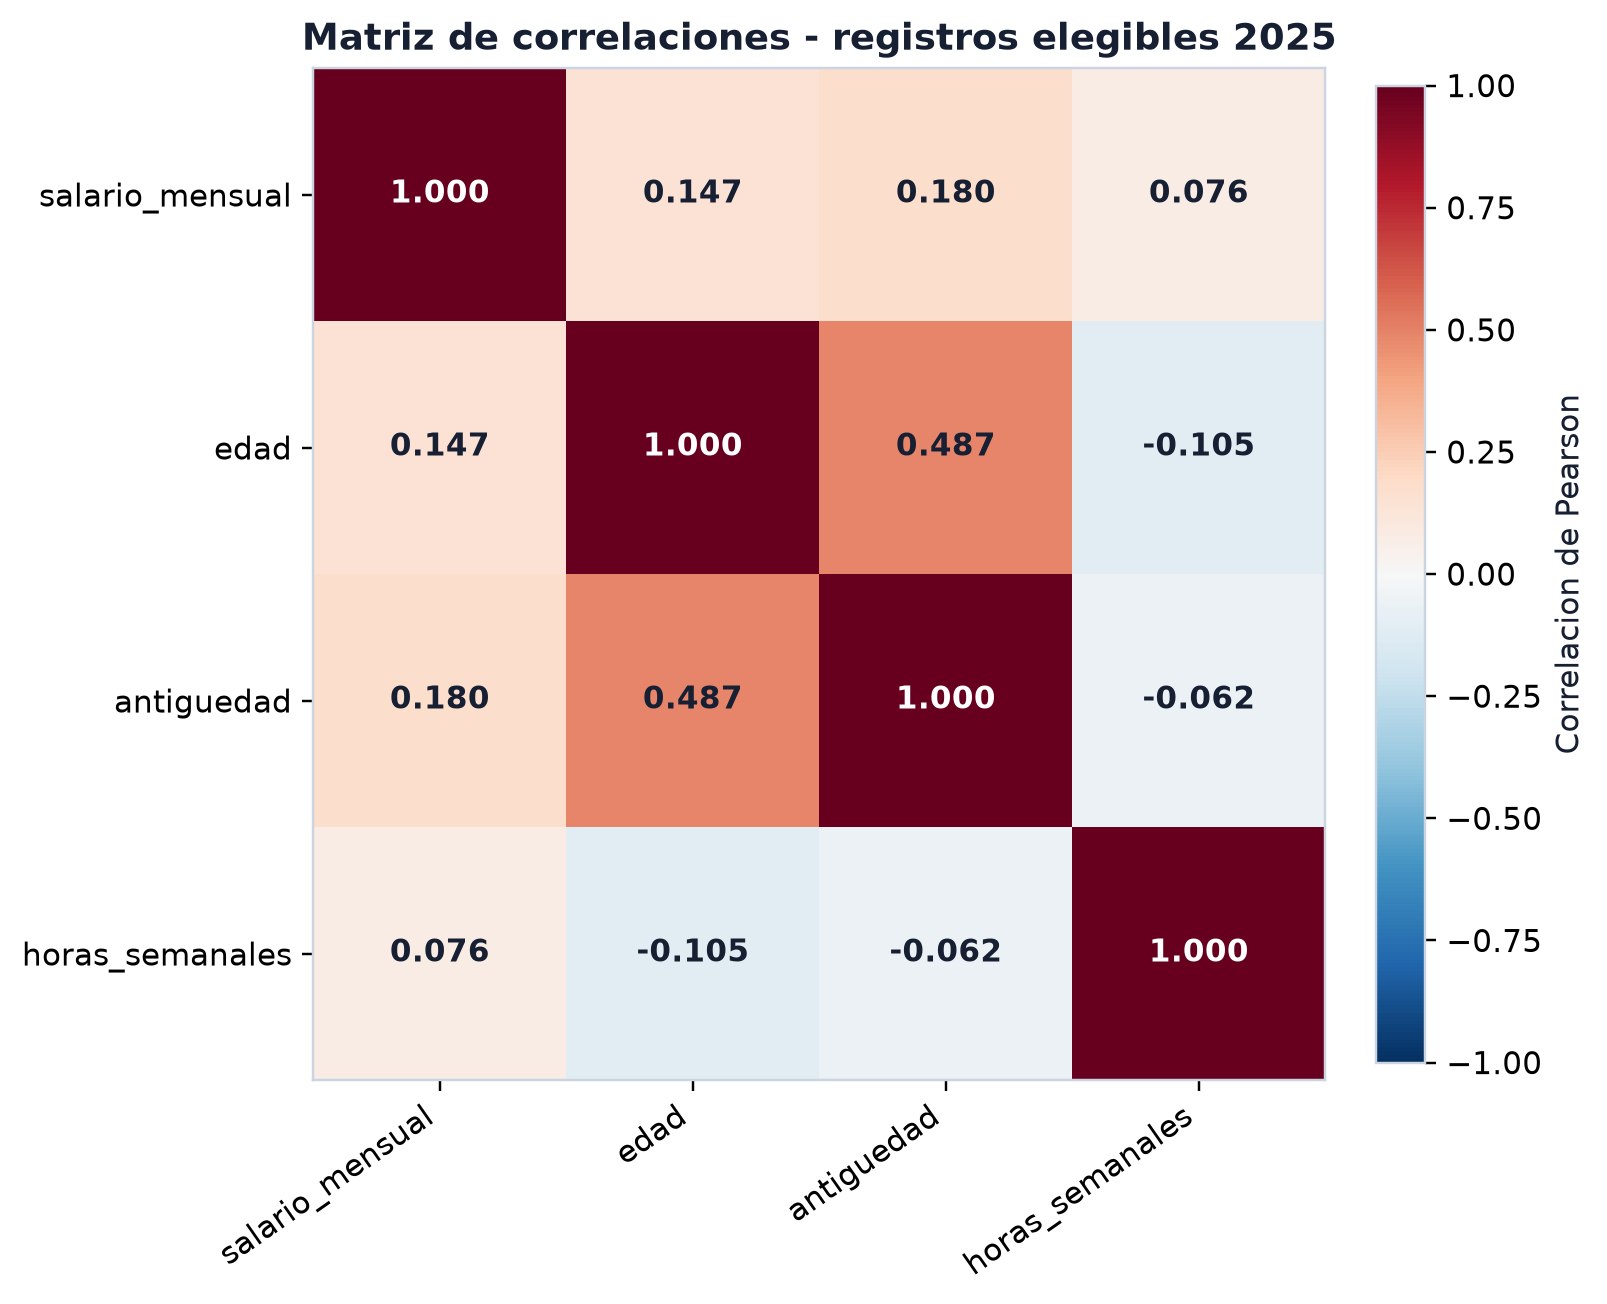

In [5]:
correlation = pearson_correlation(prepared_2025)
correlation.to_csv(TABLES_DIR / "correlaciones_pearson.csv")
plot_correlation_heatmap(correlation)
display(correlation.style.format("{:.3f}").background_gradient(cmap="RdBu_r", vmin=-1, vmax=1))
display(Image(filename=str(FIGURES_DIR / "correlaciones_pearson.png")))

salary_associations = correlation["salario_mensual"].drop("salario_mensual").abs().sort_values(ascending=False)
strongest = salary_associations.index[0]
age_tenure = correlation.loc["edad", "antiguedad"]
display(HTML(f'''
<div class='lab-note'><b>Interpretación.</b> Entre los predictores numéricos, <code>{strongest}</code> tiene la mayor asociación lineal absoluta con el salario (|r|={salary_associations.iloc[0]:.3f}). La relación edad-antigüedad es r={age_tenure:.3f}; es esperable que exista asociación, pero no equivalencia, porque personas de la misma edad pueden tener trayectorias laborales distintas.</div>
'''))

## 4. Segmentación de perfiles con KMeans

Se comparan K=2,3,4,5 en dos escenarios estandarizados: un perfil laboral sin salario y un perfil económico que sí lo incorpora. Esta comparación permite decidir con evidencia si el salario aporta separación o domina artificialmente los perfiles.

,escenario,k,silhouette
0,Perfil laboral (sin salario),2,0.5545
1,Perfil economico (con salario),2,0.5148
2,Perfil laboral (sin salario),5,0.4839
3,Perfil laboral (sin salario),4,0.4760
4,Perfil laboral (sin salario),3,0.4718
5,Perfil economico (con salario),5,0.3732
6,Perfil economico (con salario),4,0.3703
7,Perfil economico (con salario),3,0.3371


,cluster,n,edad_media,edad_mediana,antiguedad_media,antiguedad_mediana,horas_semanales_media,horas_semanales_mediana,porcentaje,descripcion
0,0,38421,29.07,28.00,2.42,1.33,48.21,46.00,72.46,"Edad bajo, antiguedad bajo, horas semanales alto"
1,1,14604,51.28,51.00,13.81,13.00,41.30,40.00,27.54,"Edad alto, antiguedad alto, horas semanales bajo"


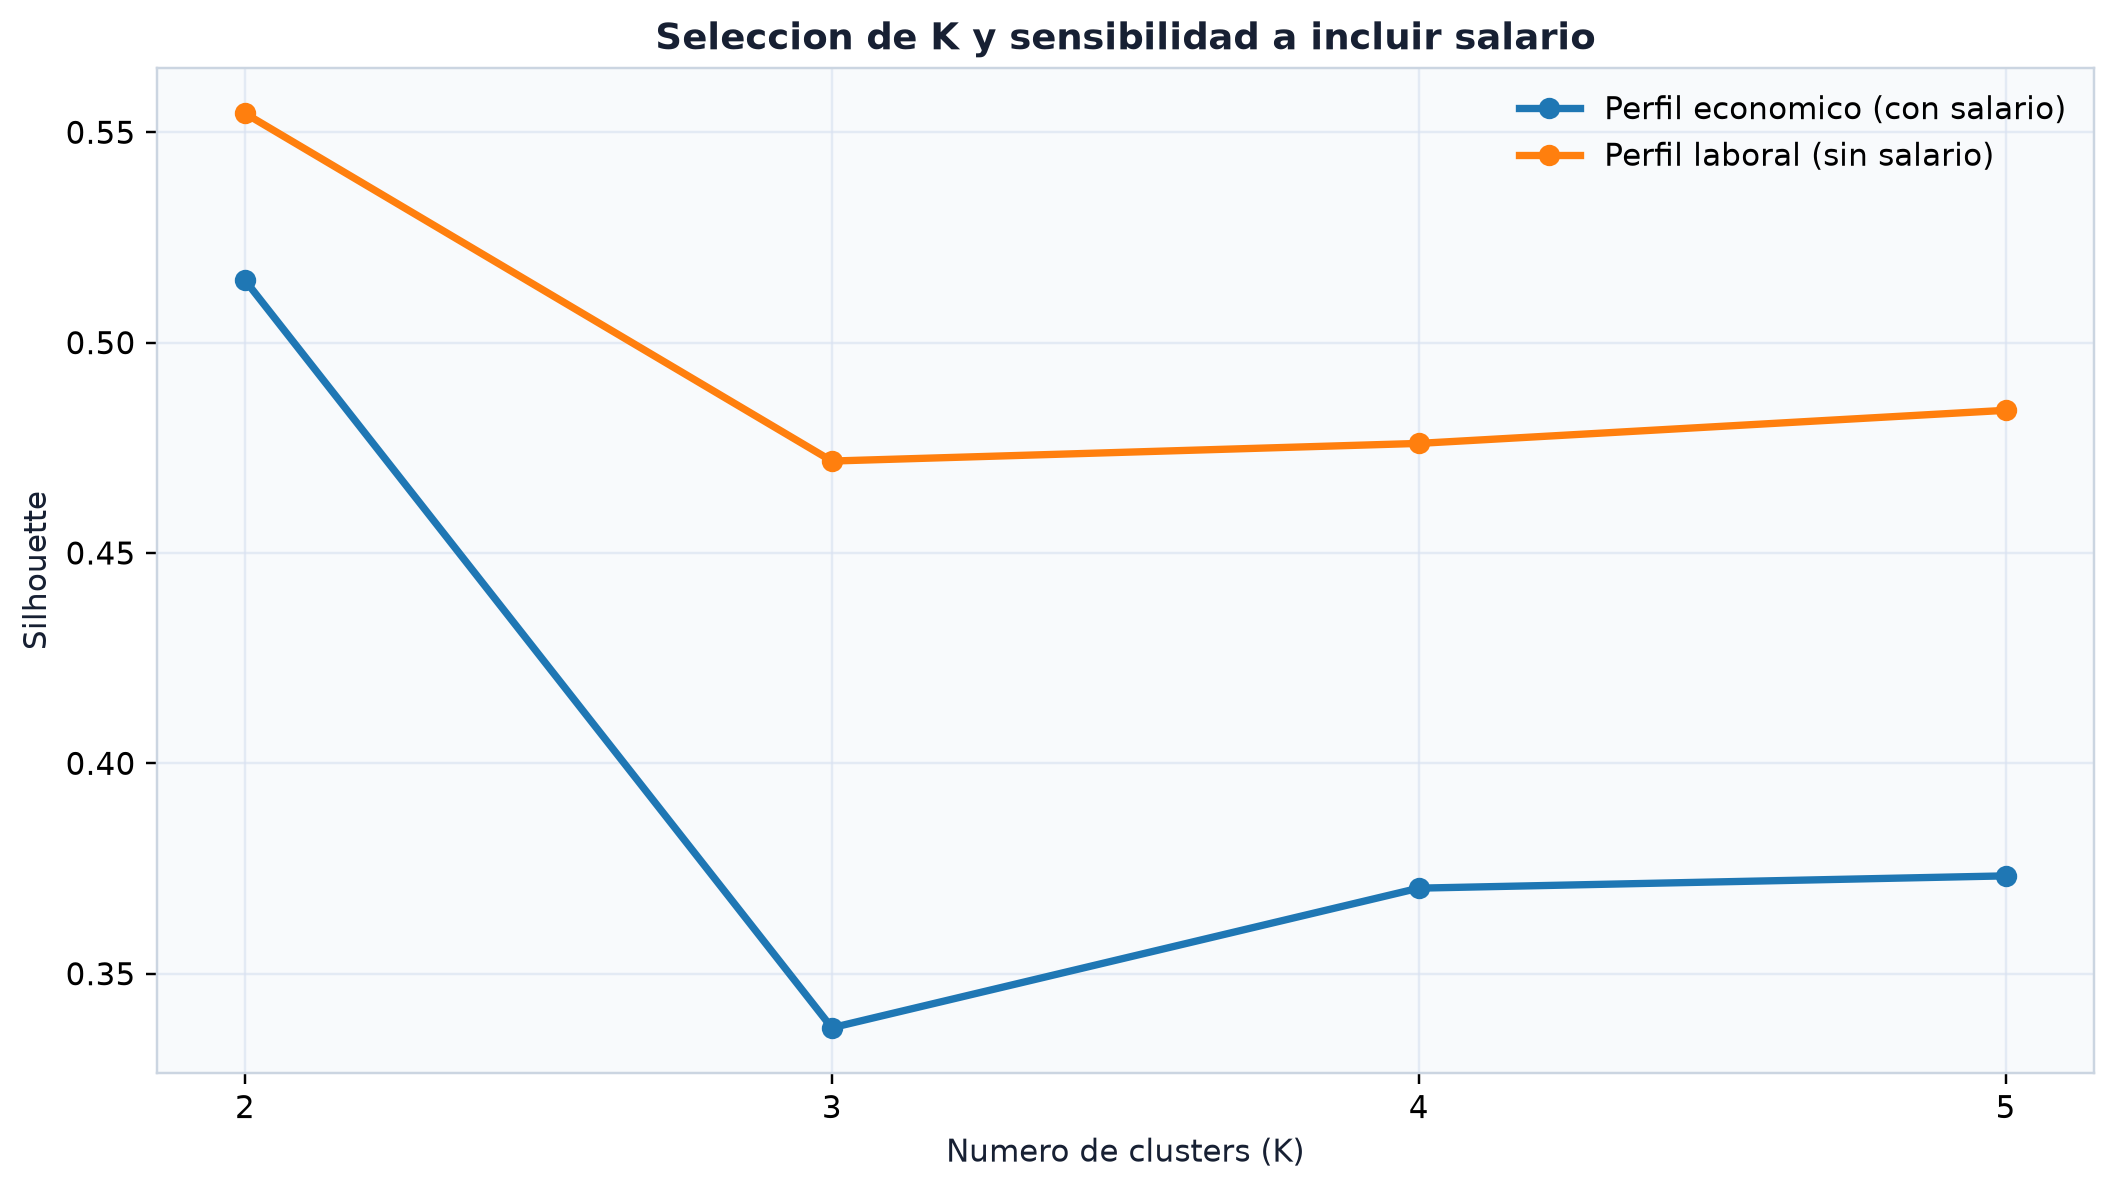

In [6]:
kmeans_results, cluster_profiles, kmeans_model, best_scenario, best_k = kmeans_search(prepared_2025)
kmeans_results.to_csv(TABLES_DIR / "seleccion_kmeans.csv", index=False)
cluster_profiles.to_csv(TABLES_DIR / "perfiles_clusters.csv", index=False)
plot_kmeans_selection(kmeans_results)

display(kmeans_results.style.format({"silhouette": "{:.4f}"}))
display(cluster_profiles.style.format({c: "{:,.2f}" for c in cluster_profiles.columns if c not in ["cluster", "n", "descripcion"]}))
display(Image(filename=str(FIGURES_DIR / "seleccion_kmeans.png")))
display(HTML(f'''
<div class='lab-note'><b>Selección:</b> el mejor resultado fue <i>{best_scenario}</i> con K={best_k}. La selección maximiza silhouette y la tabla de perfiles asigna descripciones relativas a las medias globales; son segmentos descriptivos, no clases naturales ni juicios sobre las personas.</div>
'''))

## 5–6. Modelado supervisado y validación temporal

Se usan exactamente seis predictores: edad, antigüedad, horas semanales, nivel educativo, categoría ocupacional y dominio. Todos los transformadores se ajustan únicamente con 2025T1–T3. La validación se realiza en 2025T4 y se compara contra la media salarial del entrenamiento.

,conjunto,registros
0,Entrenamiento 2025T1-T3,40361
1,Validacion 2025T4,12664
2,Test reservado 2026T1,13258


26/09/28 14:01:50 WARN Instrumentation: [c085c72a] regParam is zero, which might cause numerical instability and overfitting.


26/09/28 14:01:51 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
26/09/28 14:01:51 WARN Instrumentation: [c085c72a] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


26/09/28 14:02:30 WARN DAGScheduler: Broadcasting large task binary with size 1144.0 KiB


,nombre,regParam,elasticNetParam,MAE,RMSE,R2
0,LR_sin_regularizacion,0.000000,0.000000,"1,210.14","2,186.42",0.4257
1,LR_ridge_0_1,0.100000,0.000000,"1,210.13","2,186.42",0.4257
2,LR_elastic_0_1,0.100000,0.500000,"1,210.11","2,186.42",0.4257


,nombre,numTrees,maxDepth,MAE,RMSE,R2
0,RF_50_arboles_d7,50,7,"1,109.94","2,074.15",0.4831
1,RF_25_arboles_d5,25,5,"1,165.67","2,165.11",0.4368


,modelo,MAE,RMSE,R2
0,RF_50_arboles_d7,"1,109.94","2,074.15",0.4831
1,LR_sin_regularizacion,"1,210.14","2,186.42",0.4257
2,Referencia: media de entrenamiento,"1,672.50","2,889.57",-0.0031


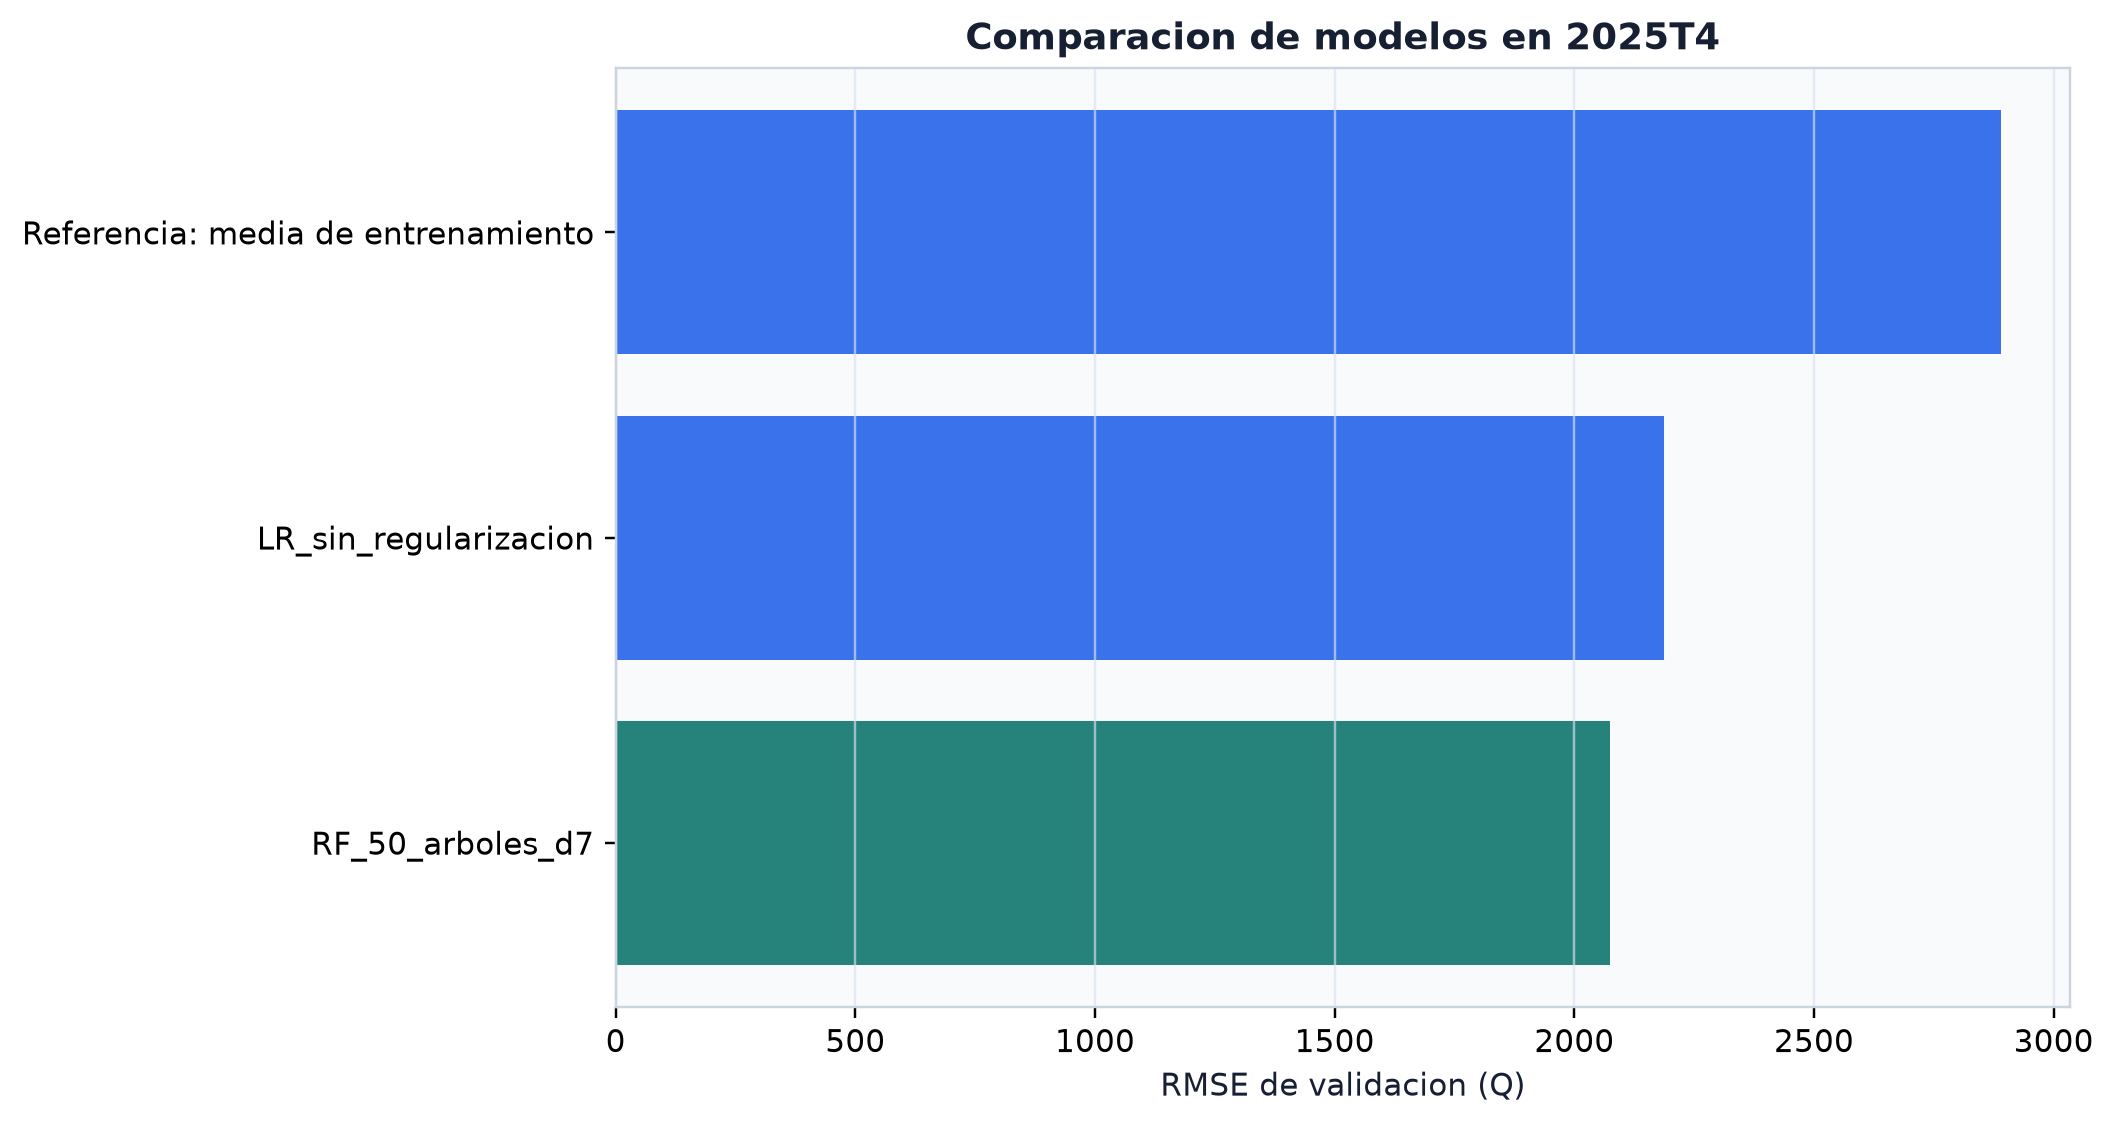

In [7]:
train = prepared_2025.filter(F.col("periodo_archivo").isin(*TRAIN_PERIODS)).cache()
validation = prepared_2025.filter(F.col("periodo_archivo").isin(*VALIDATION_PERIODS)).cache()
split_counts = pd.DataFrame({
    "conjunto": ["Entrenamiento 2025T1-T3", "Validacion 2025T4", "Test reservado 2026T1"],
    "registros": [train.count(), validation.count(), prepared_2026.count()],
})
display(split_counts)
split_counts.to_csv(TABLES_DIR / "particiones_modelado.csv", index=False)

baseline = baseline_metrics(train, validation)
linear_results, linear_model, best_linear_config = fit_linear_candidates(train, validation)
forest_results, forest_model, best_forest_config = fit_random_forest_candidates(train, validation)
comparison = comparison_table(baseline, linear_results, forest_results)

linear_results.to_csv(TABLES_DIR / "metricas_regresion_lineal.csv", index=False)
forest_results.to_csv(TABLES_DIR / "metricas_random_forest.csv", index=False)
comparison.to_csv(TABLES_DIR / "comparacion_modelos_validacion.csv", index=False)
plot_model_comparison(comparison)

display(HTML("<h4>Regresión lineal: configuraciones</h4>"))
display(linear_results.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"}))
display(HTML("<h4>Random Forest: configuraciones</h4>"))
display(forest_results.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"}))
display(HTML("<h4>Comparación con referencia</h4>"))
display(comparison.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"}))
display(Image(filename=str(FIGURES_DIR / "comparacion_modelos_validacion.png")))

winner = comparison.iloc[0]
baseline_rmse = float(comparison.loc[comparison["modelo"] == "Referencia: media de entrenamiento", "RMSE"].iloc[0])
improvement = 100 * (baseline_rmse - float(winner["RMSE"])) / baseline_rmse
display(HTML(f'''
<div class='lab-note'><b>Resultado de validación.</b> El menor RMSE corresponde a <code>{winner['modelo']}</code>: MAE Q{winner['MAE']:,.2f}, RMSE Q{winner['RMSE']:,.2f} y R² {winner['R2']:.4f}. Frente a la referencia, el RMSE mejora {improvement:.2f}%. Random Forest puede capturar relaciones no lineales e interacciones; la regresión lineal ofrece una estructura más parsimoniosa. La comparación definitiva se hace en la sección 7 con el test 2026.</div>
'''))

## 7. Entrenamiento final y evaluación en 2026

La selección de hiperparámetros ya quedó cerrada con 2025T4 en la sección anterior: se toma la configuración con menor RMSE de validación por algoritmo. Aquí **no se vuelve a escoger nada**; cada pipeline completo (`StringIndexer` → `OneHotEncoder` → `VectorAssembler` → modelo) se ajusta de nuevo con los cuatro trimestres de 2025 y se aplica una sola vez a 2026T1.

- 2026T1 pasó por las mismas reglas de preparación (`harmonize` + `filter_analytical_population`) que 2025; su embudo se guardó en `auditoria_filtros_2026.csv`.
- Ambos modelos se unen por `periodo_archivo`, `NUM_HOGAR` y `NUM_PERSONA` antes de calcular métricas, de modo que se evalúan sobre exactamente los mismos registros.
- La referencia predice la media salarial de 2025 completo (el mismo conjunto con el que se reentrenan los modelos).
- Las métricas son no ponderadas y se calculan sobre todo el test; el salario objetivo no se recorta ni se transforma.
- Residuo = salario real − salario predicho: positivo indica subestimación y negativo sobreestimación.

In [8]:
full_train_2025 = prepared_2025.filter(F.col("periodo_archivo").isin(*FINAL_TRAIN_PERIODS)).cache()
test_2026 = prepared_2026.filter(F.col("periodo_archivo").isin(*TEST_PERIODS)).cache()
assert full_train_2025.count() == prepared_2025.count(), "El reentrenamiento debe usar todo 2025"
assert test_2026.count() == prepared_2026.count()

test_key_audit = duplicate_key_audit(harmonized_2026)
assert int(test_key_audit["grupos_duplicados"].iloc[0]) == 0, "Claves duplicadas en 2026"

selected_configs = pd.DataFrame([
    {"algoritmo": "Regresion lineal", **best_linear_config,
     "RMSE_validacion_2025T4": float(linear_results.iloc[0]["RMSE"])},
    {"algoritmo": "Random Forest", **best_forest_config,
     "RMSE_validacion_2025T4": float(forest_results.iloc[0]["RMSE"])},
])
display(HTML("<h4>Configuraciones seleccionadas con 2025T4</h4>"))
display(selected_configs)

final = fit_final_models(full_train_2025, test_2026, best_linear_config, best_forest_config)
test_metrics = final["metrics"]
shared_counts = final["counts"]
final_comparison = final_comparison_table(comparison, test_metrics)

test_metrics.to_csv(TABLES_DIR / "metricas_test_2026.csv", index=False)
final_comparison.to_csv(TABLES_DIR / "comparacion_final_modelos.csv", index=False)
shared_counts.to_csv(TABLES_DIR / "conteo_test_compartido.csv", index=False)
test_key_audit.to_csv(TABLES_DIR / "auditoria_claves_2026.csv", index=False)

display(HTML("<h4>Registros de entrenamiento final y prueba</h4>"))
display(pd.DataFrame({
    "conjunto": ["Entrenamiento final 2025T1-T4", "Prueba 2026T1"],
    "registros": [final["train_rows"], final["test_rows"]],
}))
display(HTML("<h4>Mismo test para ambos modelos</h4>"))
display(shared_counts)
assert shared_counts["registros"].nunique() == 1
display(HTML("<h4>Métricas en 2026T1 (no ponderadas, test completo)</h4>"))
display(test_metrics.style.format({"MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"}))
display(HTML("<h4>Validación 2025T4 frente a prueba 2026T1</h4>"))
money = [c for c in final_comparison.columns if c.startswith(("MAE", "RMSE", "mejora", "cambio"))]
display(final_comparison.style.format({**{c: "{:,.2f}" for c in money}, "R2": "{:.4f}", "R2_validacion": "{:.4f}"}))

for name in (FINAL_LINEAR_MODEL, FINAL_FOREST_MODEL):
    assert (MODEL_DIR / name / "metadata").exists(), f"No se guardó {name}"
print("Modelos finales:", MODEL_DIR / FINAL_LINEAR_MODEL, "|", MODEL_DIR / FINAL_FOREST_MODEL)
print("Predicciones 2026 (Parquet):", final["predictions_path"])

,algoritmo,nombre,regParam,elasticNetParam,RMSE_validacion_2025T4,numTrees,maxDepth
0,Regresion lineal,LR_sin_regularizacion,0.0,0.0,2186.419579,NaN,NaN
1,Random Forest,RF_50_arboles_d7,NaN,NaN,2074.151763,50.0,7.0


26/09/28 14:02:52 WARN Instrumentation: [ef99b65f] regParam is zero, which might cause numerical instability and overfitting.


26/09/28 14:02:53 WARN Instrumentation: [ef99b65f] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


26/09/28 14:03:01 WARN DAGScheduler: Broadcasting large task binary with size 1123.9 KiB


26/09/28 14:03:27 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


,conjunto,registros
0,Entrenamiento final 2025T1-T4,53025
1,Prueba 2026T1,13258


,conjunto,registros
0,Test elegible 2026T1,13258
1,Predicciones LR_sin_regularizacion,13258
2,Predicciones RF_50_arboles_d7,13258
3,Registros compartidos (join por clave),13258
4,Claves distintas compartidas,13258


,modelo,configuracion,registros,MAE,RMSE,R2
0,Referencia: media 2025,media salarial 2025 completo,13258,"1,718.09","2,871.42",-0.0025
1,LR_sin_regularizacion,"regParam=0.0, elasticNetParam=0.0",13258,"1,240.71","2,163.75",0.4307
2,RF_50_arboles_d7,"numTrees=50, maxDepth=7",13258,"1,141.51","2,050.55",0.4887


,modelo,configuracion,registros,MAE,RMSE,R2,MAE_validacion,RMSE_validacion,R2_validacion,mejora_RMSE_vs_referencia_pct,cambio_RMSE_validacion_a_test
0,RF_50_arboles_d7,"numTrees=50, maxDepth=7",13258,"1,141.51","2,050.55",0.4887,"1,109.94","2,074.15",0.4831,28.59,-23.60
1,LR_sin_regularizacion,"regParam=0.0, elasticNetParam=0.0",13258,"1,240.71","2,163.75",0.4307,"1,210.14","2,186.42",0.4257,24.65,-22.67
2,Referencia: media 2025,media salarial 2025 completo,13258,"1,718.09","2,871.42",-0.0025,"1,672.50","2,889.57",-0.0031,0.00,-18.15


Modelos finales: /opt/app/working_dir/eneic/models/linear_regression_final_2025 | /opt/app/working_dir/eneic/models/random_forest_final_2025
Predicciones 2026 (Parquet): /opt/app/working_dir/eneic/parquet/predicciones_test_2026


In [9]:
models_only = final_comparison[~final_comparison["modelo"].str.startswith("Referencia")]
test_winner = models_only.iloc[0]
test_runner = models_only.iloc[1]
reference = final_comparison[final_comparison["modelo"].str.startswith("Referencia")].iloc[0]
validation_winner = comparison[~comparison["modelo"].str.startswith("Referencia")].iloc[0]["modelo"]
same_winner = "coincide" if validation_winner == test_winner["modelo"] else "no coincide"

display(HTML(f'''
<div class='lab-note'><b>Interpretación de la prueba 2026.</b>
<ul>
<li><b>Mejor modelo en 2026T1:</b> <code>{test_winner['modelo']}</code> con MAE Q{test_winner['MAE']:,.2f}, RMSE Q{test_winner['RMSE']:,.2f} y R² {test_winner['R2']:.4f}. El otro algoritmo (<code>{test_runner['modelo']}</code>) obtuvo MAE Q{test_runner['MAE']:,.2f}, RMSE Q{test_runner['RMSE']:,.2f} y R² {test_runner['R2']:.4f}.</li>
<li><b>Frente a la referencia:</b> la media de 2025 produce RMSE Q{reference['RMSE']:,.2f} y R² {reference['R2']:.4f}; el ganador reduce el RMSE en {test_winner['mejora_RMSE_vs_referencia_pct']:.2f}%. Que la referencia tenga R² cercano a cero es esperable, porque predice una constante.</li>
<li><b>Estabilidad temporal:</b> el RMSE del ganador cambia Q{test_winner['cambio_RMSE_validacion_a_test']:,.2f} entre validación 2025T4 y prueba 2026T1, y el ganador de validación ({validation_winner}) {same_winner} con el de prueba. Esto indica qué tan bien se sostiene fuera de tiempo la selección hecha solo con 2025.</li>
<li><b>Por qué un algoritmo generaliza mejor:</b> Random Forest captura no linealidades (por ejemplo, rendimientos decrecientes de la edad o la antigüedad) e interacciones entre educación, categoría ocupacional y dominio sin especificarlas; la regresión lineal impone efectos aditivos y constantes. Aun así, ambos dejan sin explicar una parte importante de la variabilidad: faltan variables relevantes (ocupación, rama de actividad, tamaño de empresa) y los salarios extremos pesan mucho en el RMSE.</li>
</ul>
Estas métricas describen los registros elegibles analizados; no son estimaciones oficiales ni implican causalidad.</div>
'''))

## 8. Visualización y análisis de errores

Esta sección **no reentrena ni vuelve a seleccionar nada**: lee las predicciones de 2026T1 que guardó la sección 7 (una fila por registro de prueba, con la predicción de ambos modelos) y estudia dónde se equivocan.

- **Residuo = salario real − salario predicho.** Un residuo **positivo** indica **subestimación** (el modelo predijo menos de lo observado); uno **negativo** indica **sobreestimación**.
- Los gráficos usan **una misma muestra reproducible de 5,000 registros** (orden por un hash de la clave del registro con semilla 42) para poder comparar ambos modelos sobre los mismos puntos.
- **Todas las tablas y métricas por grupo se calculan con los 13 mil y tantos registros completos de prueba**, no con la muestra gráfica, y no están ponderadas.

,modelo,n,error_medio,MAE,residuo_mediano,prop_subestimado
0,Random Forest,13258,107.45,"1,141.51",-69.63,47.0%
1,Regresión lineal,13258,120.55,"1,240.71",-31.64,48.9%


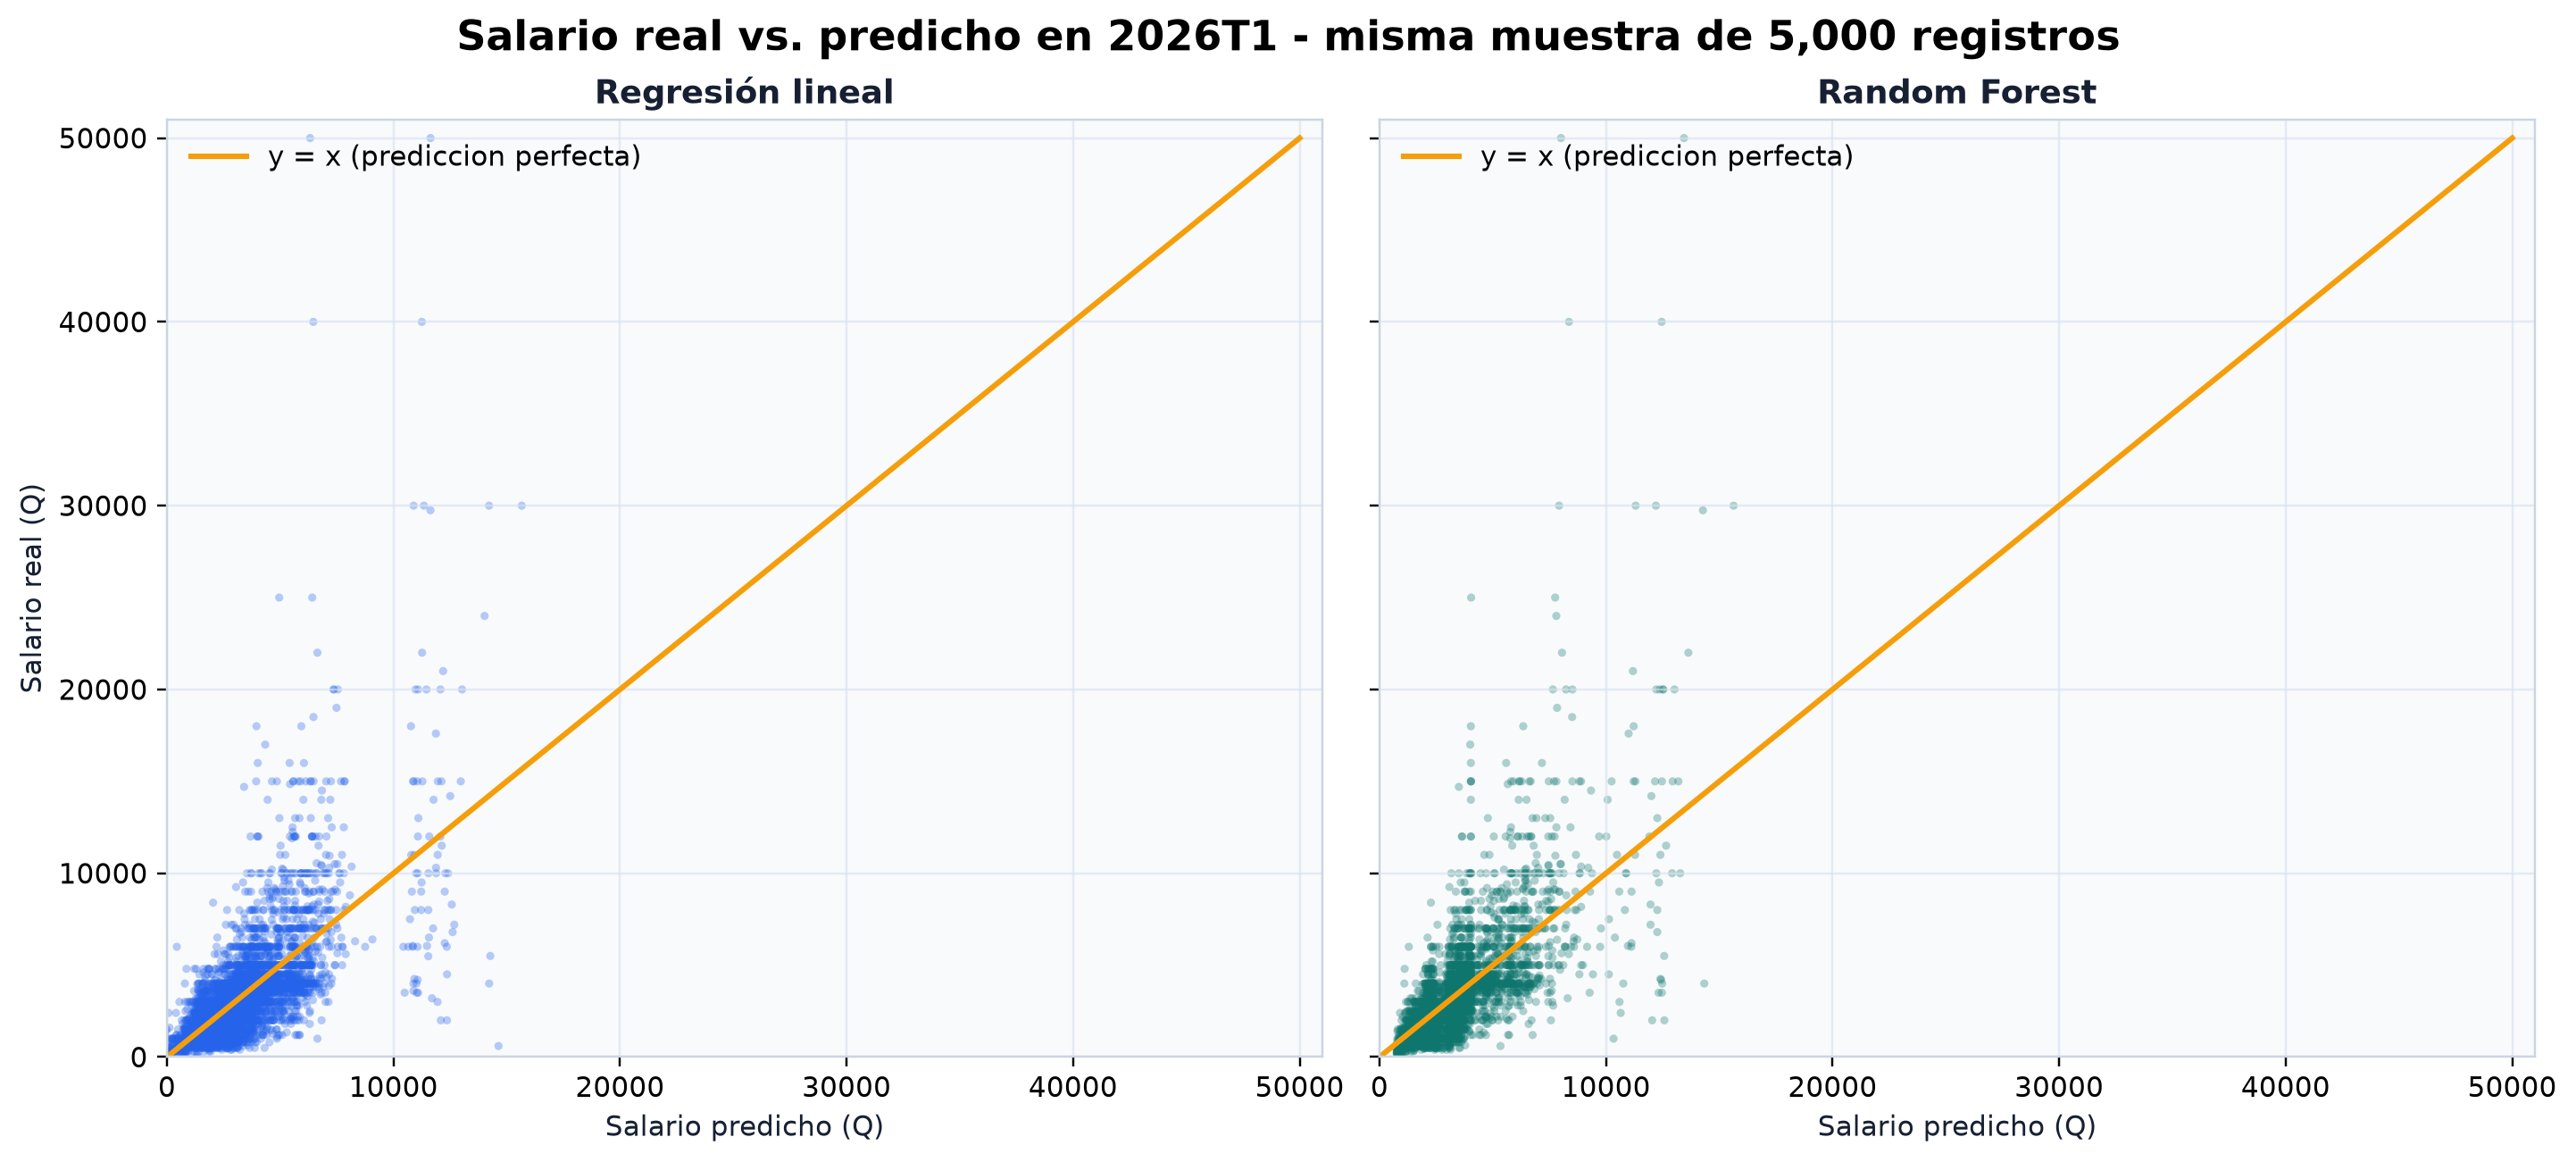

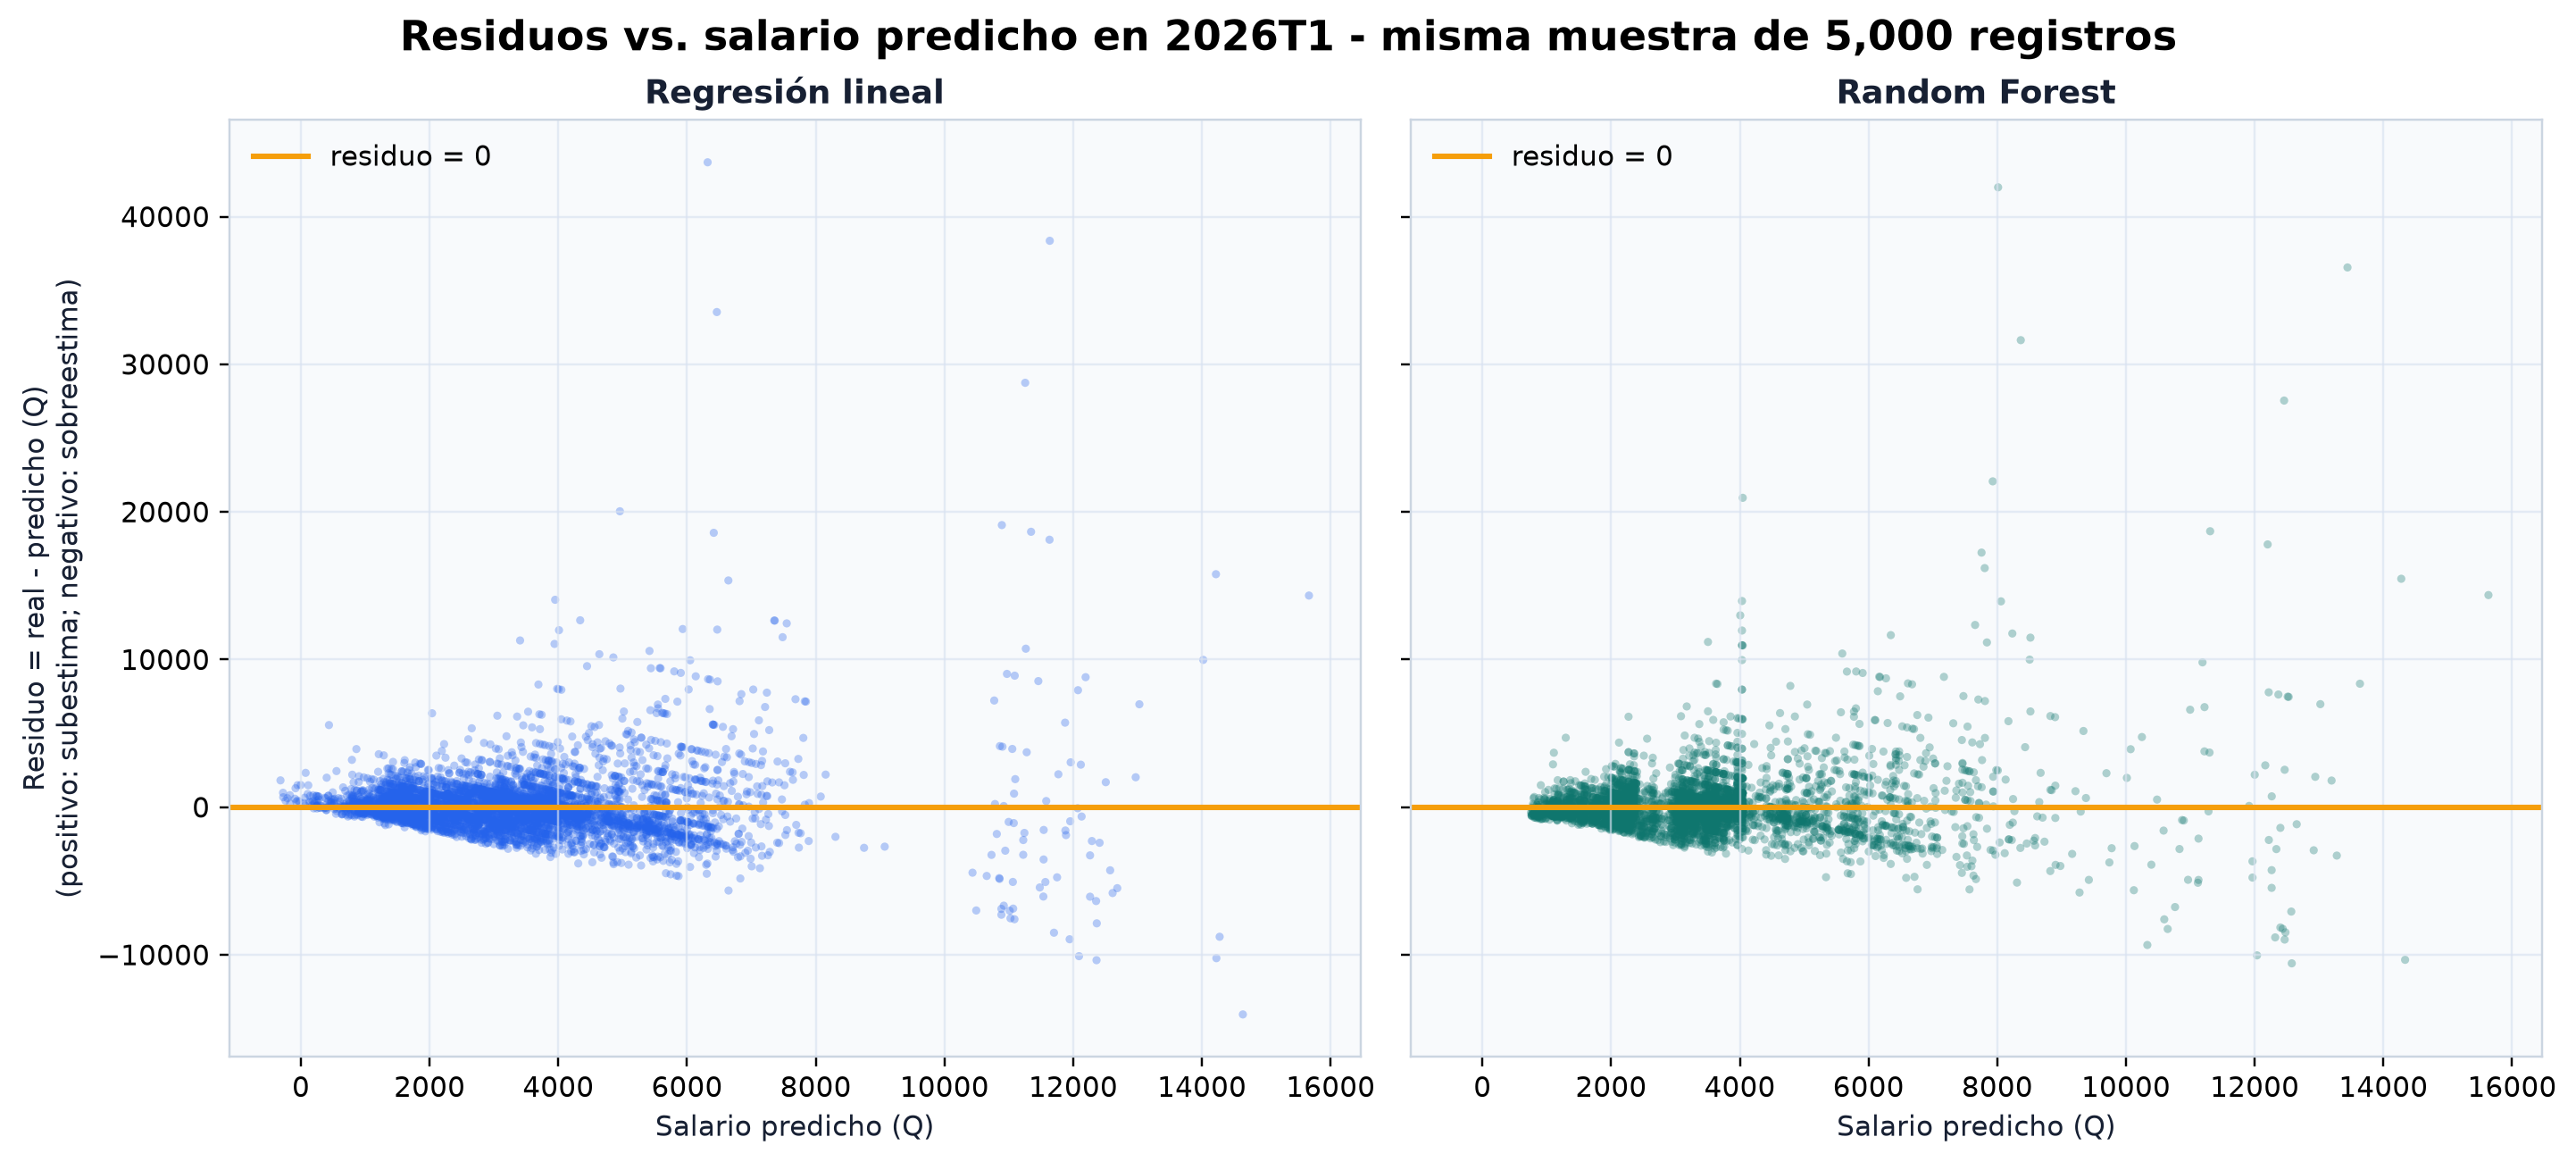

In [10]:
predictions_2026 = load_test_predictions(spark).cache()
n_predictions = predictions_2026.count()
n_keys = predictions_2026.select("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA").distinct().count()
assert n_predictions == n_keys == test_2026.count(), "Las predicciones deben cubrir exactamente el test 2026"

# Coherencia con la sección 7: las métricas recalculadas desde el Parquet deben coincidir.
recomputed = residual_summary(predictions_2026)
for algorithm, column in (("Regresión lineal", "prediccion_lr"), ("Random Forest", "prediccion_rf")):
    mae_here = float(recomputed.loc[recomputed["modelo"] == algorithm, "MAE"].iloc[0])
    row = test_metrics[test_metrics["modelo"].str.startswith("LR" if column == "prediccion_lr" else "RF")].iloc[0]
    assert abs(mae_here - float(row["MAE"])) < 1e-6, f"MAE inconsistente para {algorithm}"

plot_sample = plot_comparison_sample(predictions_2026, 5_000)
assert len(plot_sample) <= 5_000
plot_actual_vs_predicted(plot_sample)
plot_residuals(plot_sample)
recomputed.to_csv(TABLES_DIR / "resumen_residuos_2026.csv", index=False)

display(HTML(f"<h4>Registros de prueba: {n_predictions:,} (mismas claves para ambos modelos) · muestra gráfica: {len(plot_sample):,}</h4>"))
display(HTML("<h4>Residuos globales sobre todo el test (residuo = real − predicho)</h4>"))
display(recomputed.style.format({"error_medio": "{:,.2f}", "MAE": "{:,.2f}", "residuo_mediano": "{:,.2f}", "prop_subestimado": "{:.1%}"}))
display(Image(filename=str(FIGURES_DIR / "real_vs_predicho_2026.png")))
display(Image(filename=str(FIGURES_DIR / "residuos_vs_predicho_2026.png")))

In [11]:
summary = recomputed.set_index("modelo")
plot_reading = plot_findings(plot_sample)
(TABLES_DIR / "interpretacion_graficos_2026.txt").write_text(plot_reading, encoding="utf-8")
lines = []
for model in summary.index:
    mean_error = float(summary.loc[model, "error_medio"])
    lines.append(
        f"- **{model}:** error medio global {mean_error:+,.2f} Q "
        f"({'subestima' if mean_error > 0 else 'sobreestima'} en promedio); "
        f"subestima al {summary.loc[model, 'prop_subestimado']:.1%} de los registros."
    )
display(Markdown(
    "### Interpretación de los gráficos de predicción y residuos\n\n"
    "**Cómo leerlos.** En el gráfico real vs. predicho, una predicción perfecta caería sobre la línea y = x: "
    "los puntos **por encima** de la línea son salarios reales mayores que la predicción (subestimación) y los "
    "puntos por debajo son sobreestimaciones. En el gráfico de residuos, la línea en cero separa subestimación "
    "(arriba) de sobreestimación (abajo); una nube sin estructura alrededor de cero indicaría un ajuste sin sesgo "
    "sistemático.\n\n"
    "**Resultados globales (todo el test).**\n\n" + "\n".join(lines) + "\n\n"
    "**Lo que muestran las gráficas (muestra común de 5,000 registros).**\n\n" + plot_reading + "\n\n"
    "_Estas lecturas usan la muestra gráfica; las métricas y tablas por grupo se calculan con todo el test._"
))

### Interpretación de los gráficos de predicción y residuos

**Cómo leerlos.** En el gráfico real vs. predicho, una predicción perfecta caería sobre la línea y = x: los puntos **por encima** de la línea son salarios reales mayores que la predicción (subestimación) y los puntos por debajo son sobreestimaciones. En el gráfico de residuos, la línea en cero separa subestimación (arriba) de sobreestimación (abajo); una nube sin estructura alrededor de cero indicaría un ajuste sin sesgo sistemático.

**Resultados globales (todo el test).**

- **Random Forest:** error medio global +107.45 Q (subestima en promedio); subestima al 47.0% de los registros.
- **Regresión lineal:** error medio global +120.55 Q (subestima en promedio); subestima al 48.9% de los registros.

**Lo que muestran las gráficas (muestra común de 5,000 registros).**

- **Regresion lineal:** en la muestra, el residuo medio es Q105.62; para salarios reales desde el percentil 90 es Q3,282.91. La dispersion crece con el nivel salarial, por lo que los errores no tienen varianza constante.
- **Random Forest:** en la muestra, el residuo medio es Q95.47; para salarios reales desde el percentil 90 es Q3,202.76. La dispersion crece con el nivel salarial, por lo que los errores no tienen varianza constante.

_Estas lecturas usan la muestra gráfica; las métricas y tablas por grupo se calculan con todo el test._

### 8.1 Errores por nivel educativo y por dominio

Para cada grupo se reportan el **número de observaciones**, el **MAE** y el **error medio** (real − predicho; positivo = subestima) con todos los registros de prueba.

,modelo,grupo,n,MAE,error_medio,salario_promedio,tendencia
0,Random Forest,Ninguno,"1,016",708.92,-197.02,"1,884.14",sobreestima
1,Random Forest,Preprimaria,80,661.81,-192.45,"2,374.56",sobreestima
2,Random Forest,Primaria,"3,957",777.34,-6.77,"2,422.75",sobreestima
3,Random Forest,Basico,"2,164",850.43,54.88,"2,905.46",subestima
4,Random Forest,Diversificado,"4,117","1,045.38",200.09,"3,924.24",subestima
5,Random Forest,Superior,"1,729","2,358.83",342.58,"6,264.36",subestima
6,Random Forest,Maestria,183,"4,882.13",39.54,"11,290.64",subestima
7,Random Forest,Doctorado,12,"14,088.18","10,397.51","20,291.67",subestima
8,Regresión lineal,Ninguno,"1,016",823.51,109.34,"1,884.14",subestima
9,Regresión lineal,Preprimaria,80,735.21,88.76,"2,374.56",subestima


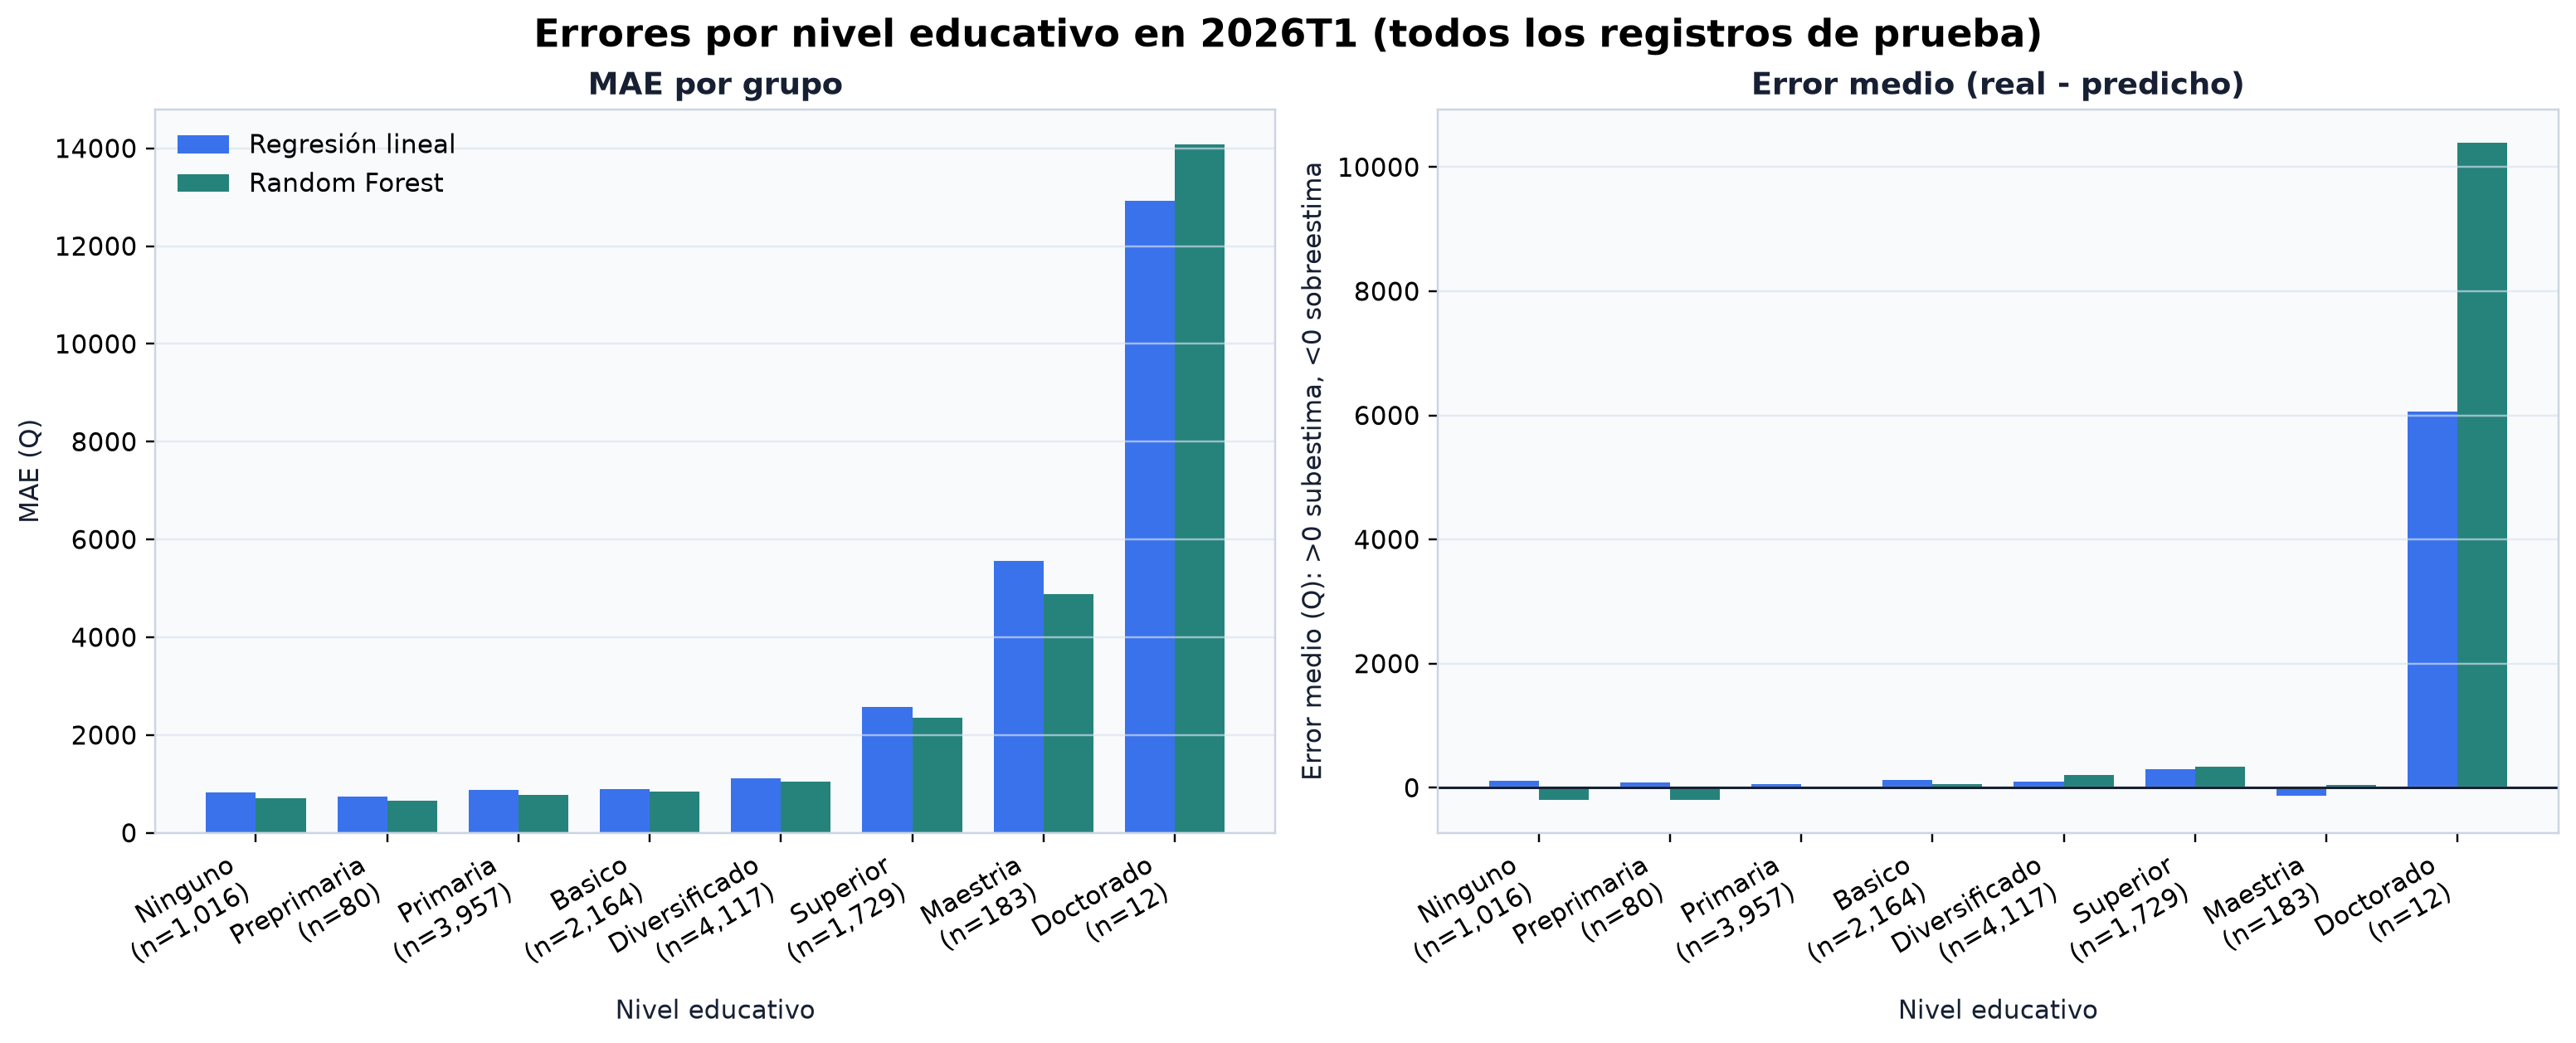

,modelo,grupo,n,MAE,error_medio,salario_promedio,tendencia
0,Random Forest,Resto Urbano,"4,846","1,085.55",66.32,"3,281.64",subestima
1,Random Forest,Rural Nacional,"2,780",813.65,-62.41,"2,467.73",sobreestima
2,Random Forest,Urbano Metropolitano,"5,632","1,351.50",226.68,"4,352.31",subestima
3,Regresión lineal,Resto Urbano,"4,846","1,189.65",134.28,"3,281.64",subestima
4,Regresión lineal,Rural Nacional,"2,780",913.64,65.24,"2,467.73",subestima
5,Regresión lineal,Urbano Metropolitano,"5,632","1,446.09",136.04,"4,352.31",subestima


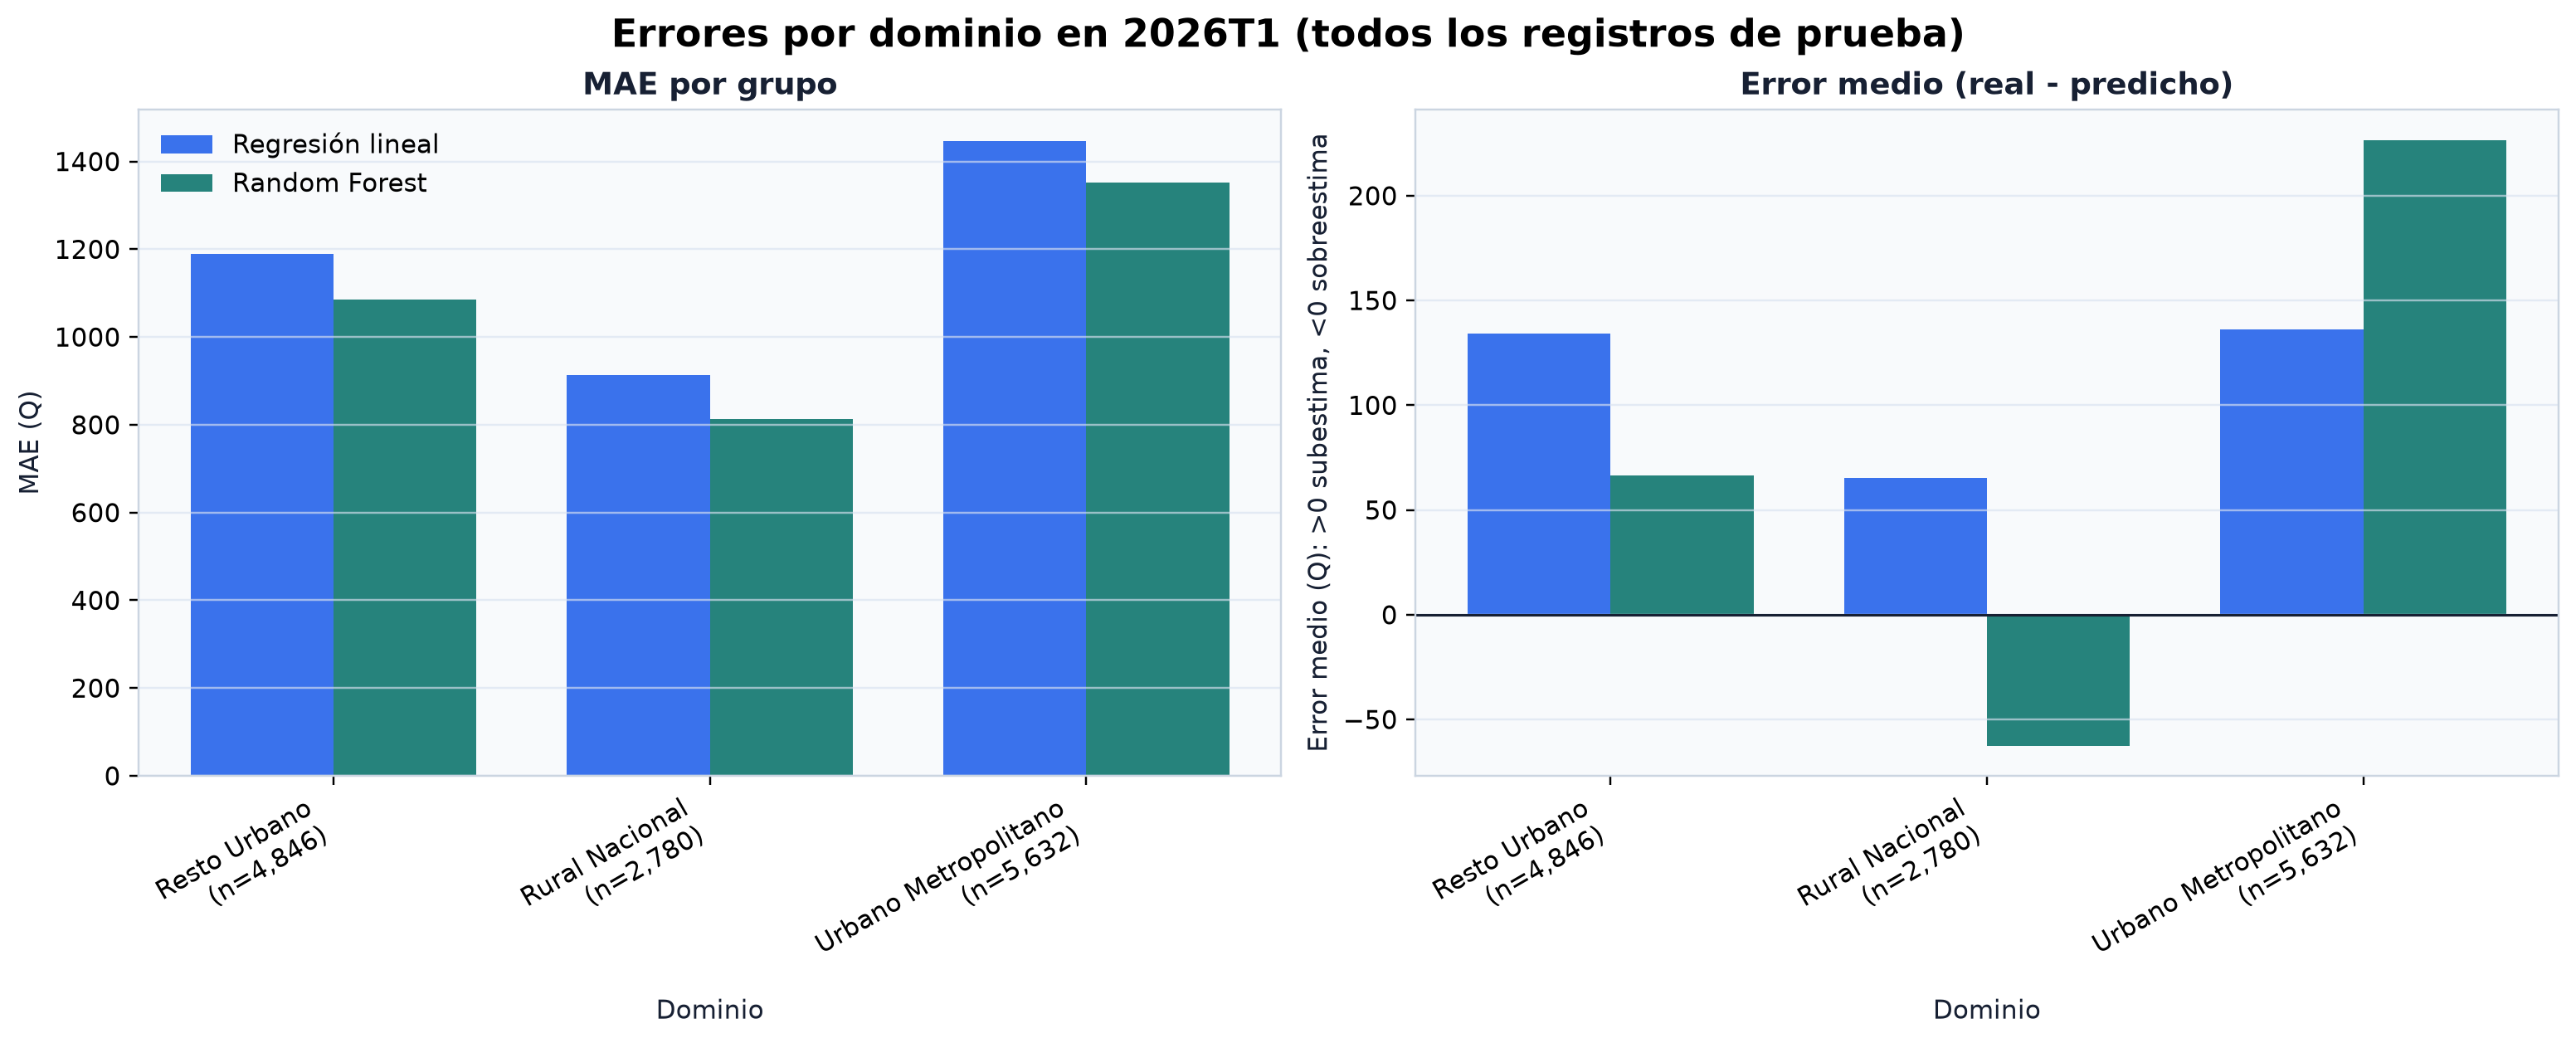

In [12]:
by_education = error_by_group(predictions_2026, "nivel_educativo")
by_domain = error_by_group(predictions_2026, "dominio")
by_education.to_csv(TABLES_DIR / "errores_por_educacion_2026.csv", index=False)
by_domain.to_csv(TABLES_DIR / "errores_por_dominio_2026.csv", index=False)
plot_errors_by_education(by_education)
plot_errors_by_domain(by_domain)

fmt = {"n": "{:,}", "MAE": "{:,.2f}", "error_medio": "{:,.2f}", "salario_promedio": "{:,.2f}"}
display(HTML("<h4>Por nivel educativo</h4>"))
display(by_education.drop(columns="variable").style.format(fmt))
display(Image(filename=str(FIGURES_DIR / "errores_por_educacion_2026.png")))
display(HTML("<h4>Por dominio</h4>"))
display(by_domain.drop(columns="variable").style.format(fmt))
display(Image(filename=str(FIGURES_DIR / "errores_por_dominio_2026.png")))

In [13]:
display(Markdown(
    "### Interpretación por nivel educativo\n\n" + group_findings(by_education, "nivel educativo") + "\n\n"
    + salary_scale_sentence(by_education, "nivel educativo") + " Un error medio positivo significa que, en promedio, "
    "el modelo predijo menos de lo observado para ese grupo.\n\n"
    "### Interpretación por dominio\n\n" + group_findings(by_domain, "dominio") + "\n\n"
    + salary_scale_sentence(by_domain, "dominio")
))

### Interpretación por nivel educativo

- **Random Forest:** el mayor MAE por nivel educativo aparece en **Doctorado** (Q14,088.18, n=12). La mayor subestimacion media ocurre en **Doctorado** (Q10,397.51) y la mayor sobreestimacion en **Ninguno** (Q-197.02).
- **Regresión lineal:** el mayor MAE por nivel educativo aparece en **Doctorado** (Q12,919.31, n=12). La mayor subestimacion media ocurre en **Doctorado** (Q6,062.70) y la mayor sobreestimacion en **Maestria** (Q-131.50).

El grupo de nivel educativo con mayor salario promedio es **Doctorado** (Q20,291.67) y tambien concentra el mayor MAE absoluto; esto obliga a interpretar el MAE junto con la escala salarial y el numero de observaciones. Un error medio positivo significa que, en promedio, el modelo predijo menos de lo observado para ese grupo.

### Interpretación por dominio

- **Random Forest:** el mayor MAE por dominio aparece en **Urbano Metropolitano** (Q1,351.50, n=5,632). La mayor subestimacion media ocurre en **Urbano Metropolitano** (Q226.68) y la mayor sobreestimacion en **Rural Nacional** (Q-62.41).
- **Regresión lineal:** el mayor MAE por dominio aparece en **Urbano Metropolitano** (Q1,446.09, n=5,632). La mayor subestimacion media ocurre en **Urbano Metropolitano** (Q136.04) y la mayor sobreestimacion en **Rural Nacional** (Q65.24).

El grupo de dominio con mayor salario promedio es **Urbano Metropolitano** (Q4,352.31) y tambien concentra el mayor MAE absoluto; esto obliga a interpretar el MAE junto con la escala salarial y el numero de observaciones.

### 8.2 Errores según el percentil del salario

Se divide el test en bandas del **salario real** de 2026T1 (P0–P25, P25–P50, P50–P75, P75–P90, P90–P95 y P95–P100; los cortes salen del test completo con `approxQuantile`). Como muchos salarios se repiten en cifras redondas, las bandas se cierran por la derecha y la tabla informa su tamaño real.

**Advertencia de lectura:** agrupar por el salario real induce, incluso en un modelo razonable, una sobreestimación en las bandas bajas y una subestimación en las altas (regresión a la media). Por eso el hallazgo importa sobre todo por su **magnitud** y por compararlo entre algoritmos.

,banda,salario_limite_superior
0,P00-P25,"2,000.00"
1,P25-P50,"3,200.00"
2,P50-P75,"4,066.00"
3,P75-P90,"6,000.00"
4,P90-P95,"8,000.00"
5,P95-P100,—


,modelo,banda,n,salario_promedio,prediccion_promedio,MAE,error_medio,prop_subestimado,salario_limite_superior,error_medio_pct_salario,tendencia
0,Random Forest,P00-P25,"4,032","1,297.68","2,166.17",928.37,-868.49,10.9%,"2,000.00",-66.9%,sobreestima
1,Random Forest,P25-P50,"2,715","2,738.19","2,947.24",700.88,-209.05,42.5%,"3,200.00",-7.6%,sobreestima
2,Random Forest,P50-P75,"3,188","3,769.05","3,794.60",691.34,-25.55,60.5%,"4,066.00",-0.7%,sobreestima
3,Random Forest,P75-P90,"2,072","4,888.55","4,337.56","1,200.13",550.99,75.3%,"6,000.00",+11.3%,subestima
4,Random Forest,P90-P95,608,"7,224.81","5,581.09","2,048.32","1,643.73",88.3%,"8,000.00",+22.8%,subestima
5,Random Forest,P95-P100,643,"12,552.71","7,211.67","5,524.16","5,341.04",94.4%,—,+42.5%,subestima
6,Regresión lineal,P00-P25,"4,032","1,297.68","2,126.41",998.39,-828.73,21.2%,"2,000.00",-63.9%,sobreestima
7,Regresión lineal,P25-P50,"2,715","2,738.19","2,899.27",851.68,-161.09,47.4%,"3,200.00",-5.9%,sobreestima
8,Regresión lineal,P50-P75,"3,188","3,769.05","3,848.70",830.82,-79.64,55.0%,"4,066.00",-2.1%,sobreestima
9,Regresión lineal,P75-P90,"2,072","4,888.55","4,402.37","1,177.65",486.18,69.4%,"6,000.00",+9.9%,subestima


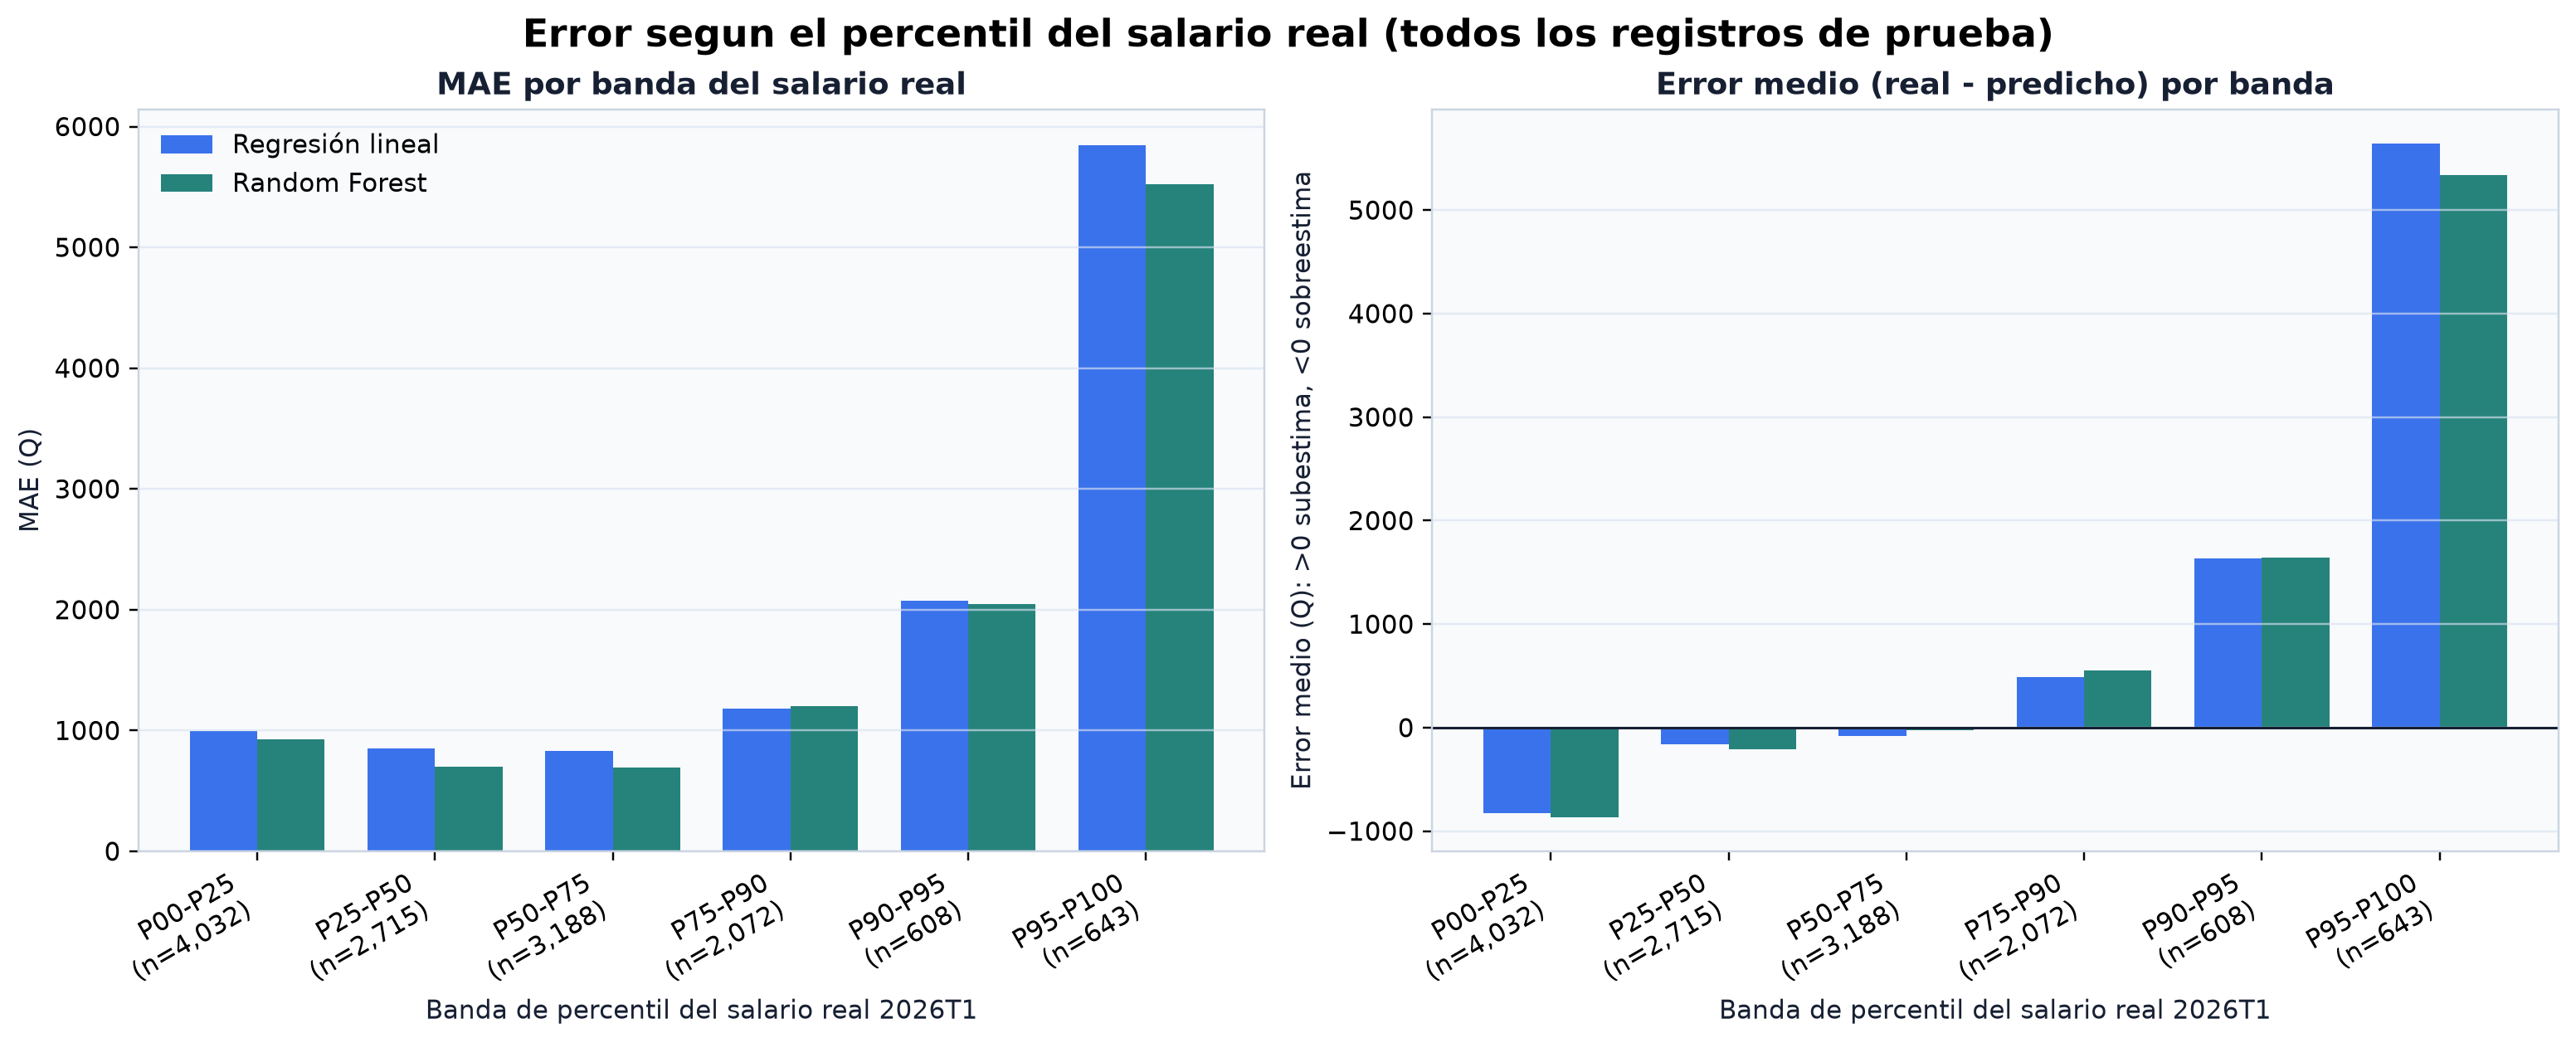

In [14]:
banded, thresholds = salary_percentile_bands(predictions_2026)
by_band = error_by_salary_band(banded, thresholds)
by_band.to_csv(TABLES_DIR / "errores_por_percentil_salarial_2026.csv", index=False)
plot_errors_by_salary_band(by_band)

display(HTML("<h4>Cortes de percentil del salario real (Q)</h4>"))
display(thresholds.style.format({"salario_limite_superior": "{:,.2f}"}, na_rep="—"))
display(HTML("<h4>Error por banda y modelo</h4>"))
display(by_band.style.format({
    "n": "{:,}", "salario_promedio": "{:,.2f}", "prediccion_promedio": "{:,.2f}", "MAE": "{:,.2f}",
    "error_medio": "{:,.2f}", "prop_subestimado": "{:.1%}", "salario_limite_superior": "{:,.2f}",
    "error_medio_pct_salario": "{:+.1f}%",
}, na_rep="—"))
display(Image(filename=str(FIGURES_DIR / "errores_por_percentil_salarial_2026.png")))

In [15]:
display(Markdown(
    "### Interpretación por percentil salarial\n\n" + band_findings(by_band) + "\n\n"
    "**Salarios bajos, medios y altos.** " + band_context(test_metrics, by_band)
))

### Interpretación por percentil salarial

- **Random Forest:** en P00-P25 el error medio es Q-868.49; en P95-P100 asciende a Q5,341.04, con MAE Q5,524.16 y 94.4% de registros subestimados.
- **Regresión lineal:** en P00-P25 el error medio es Q-828.73; en P95-P100 asciende a Q5,645.34, con MAE Q5,848.39 y 94.4% de registros subestimados.

**Salarios bajos, medios y altos.** **RF_50_arboles_d7** es el mejor modelo global por RMSE. Sin embargo, en P95-P100 todavia presenta un error medio de Q5,341.04 y un MAE de Q5,524.16; por tanto, una mejora promedio no elimina la dificultad de representar la cola salarial.

### 8.3 Respuestas a las preguntas de la actividad

In [16]:
display(Markdown(question_answers(test_metrics, by_education, by_domain, by_band)))

- **Algoritmo con mejor generalizacion:** RF_50_arboles_d7, con RMSE Q2,050.55 y R2=0.4887, frente a RMSE Q2,163.75 del otro algoritmo.
- **Nivel educativo con mayor error observado:** Doctorado para Random Forest (MAE Q14,088.18, n=12).
- **Dominio con mayor error observado:** Urbano Metropolitano para Regresión lineal (MAE Q1,446.09, n=5,632).
- **Banda mas dificil:** P95-P100 para Regresión lineal (MAE Q5,848.39). Los errores medios positivos en la cola alta indican subestimacion sistematica de salarios altos.
- **Lectura correcta:** las diferencias son predictivas y descriptivas; no prueban causalidad ni determinan cuanto deberia ganar una persona.

## Conclusiones finales

In [17]:
display(Markdown(final_discussion(test_metrics, by_education, by_domain, by_band)))

El analisis identifico perfiles laborales diferenciados y demostro que **RF_50_arboles_d7** generaliza mejor a 2026T1: MAE Q1,141.51, RMSE Q2,050.55 y R2=0.4887. Su RMSE es 28.59% menor que el de la referencia y tambien supera a LR_sin_regularizacion. La ventaja es compatible con la capacidad del bosque para representar no linealidades e interacciones entre educacion, ocupacion y territorio.

El desempeño no es uniforme. El mayor MAE por educacion se observo en **Doctorado**, y por dominio en **Urbano Metropolitano**. En la banda P95-P100, el ganador conserva un MAE de Q5,524.16 y un error medio de Q5,341.04, evidencia de que la cola salarial sigue siendo dificil y tiende a subestimarse. El patron debe interpretarse junto con el tamaño de cada grupo y la regresion a la media.

Las metricas son no ponderadas y describen solamente asalariados elegibles con salario positivo registrado. No representan estimaciones oficiales de Guatemala ni efectos causales. La ausencia de variables como rama de actividad, ocupacion detallada o tamaño de empresa limita la varianza explicada; un uso posterior deberia estudiar estabilidad temporal, equidad por subgrupos y estimaciones ponderadas con FACTOR bajo el diseño muestral correspondiente.

### Estado de las actividades

| Actividad | Estado |
|---|---|
| 1. Carga, armonización y calidad | Completa |
| 2. Estadística descriptiva | Completa |
| 3. Correlaciones con MLlib | Completa |
| 4. Segmentación KMeans | Completa |
| 5. Pipeline de regresión lineal | Completa |
| 6. Pipeline de Random Forest | Completa |
| 7. Entrenamiento final y evaluación en 2026 | Completa |
| 8. Visualización y análisis de errores | Completa |

In [18]:
progress = pd.DataFrame({
    "actividad": [
        "1. Carga, armonizacion y calidad", "2. Estadistica descriptiva", "3. Correlaciones",
        "4. KMeans", "5. Regresion lineal", "6. Random Forest",
        "7. Evaluacion final 2026", "8. Analisis de errores",
    ],
    "estado": ["Completo"] * 8,
})
progress.to_csv(TABLES_DIR / "estado_avance.csv", index=False)

# Liberación explícita de caché al terminar la ejecución reproducible.
for frame in [raw_2025, raw_2026, harmonized_2025, harmonized_2026, prepared_2025, prepared_2026,
              train, validation, full_train_2025, test_2026, predictions_2026]:
    frame.unpersist()
print("Notebook ejecutado correctamente de principio a fin. Spark queda disponible para inspección interactiva.")

Notebook ejecutado correctamente de principio a fin. Spark queda disponible para inspección interactiva.
